In [21]:
import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
import rasterio
from pathlib import Path
import gdal_tools
import matplotlib.colors as colors
import xarray as xr


#model outputs
path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/'
path_3d = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d/'


#smap satelite data
smap_sat = "/scratch/alpine/battobrah@xsede.org/smap_monthly_smc_4326/"

#print(path_pp)
#print(path_3d)


outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

path = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d/'

# ------------------------------------
# READ TIME FROM INPUT FILE (REQUIRED)
# ------------------------------------
fp = nc.Dataset(path_3d + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

# ------------------------------------
# BUILD DATETIME VECTOR (PROF STYLE)
# ------------------------------------
start = pd.Timestamp("2016-01-01 00:00")

datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

times = pd.Series(datetime_series, name="datetime")


# Read HRU grid + metadata (Read spatial rasters that map grid cells to HRUs)
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 250     #trim off 250 pixels around the edges of the domain.
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

with rasterio.open(path + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)   # read cluster ids

# Force HRU count to match model outputs (1000)
with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
    nhrus = ds.groups["data"].variables["totsmc"].shape[1]

def read_grid(fp):      # read raster grid
    with rasterio.open(fp) as ds:
        arr = ds.read(1).astype(np.float32)
        nod = ds.nodata
        if nod is not None:
            arr[arr == nod] = np.nan
        arr[arr == -9999.0] = np.nan
        return arr
      
def place_data(tmp, model, hrus, cids, val):    #tmp: an empty 2D grid template
    out = np.copy(tmp)                          #a 1D array of HRU values from the model
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru  = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


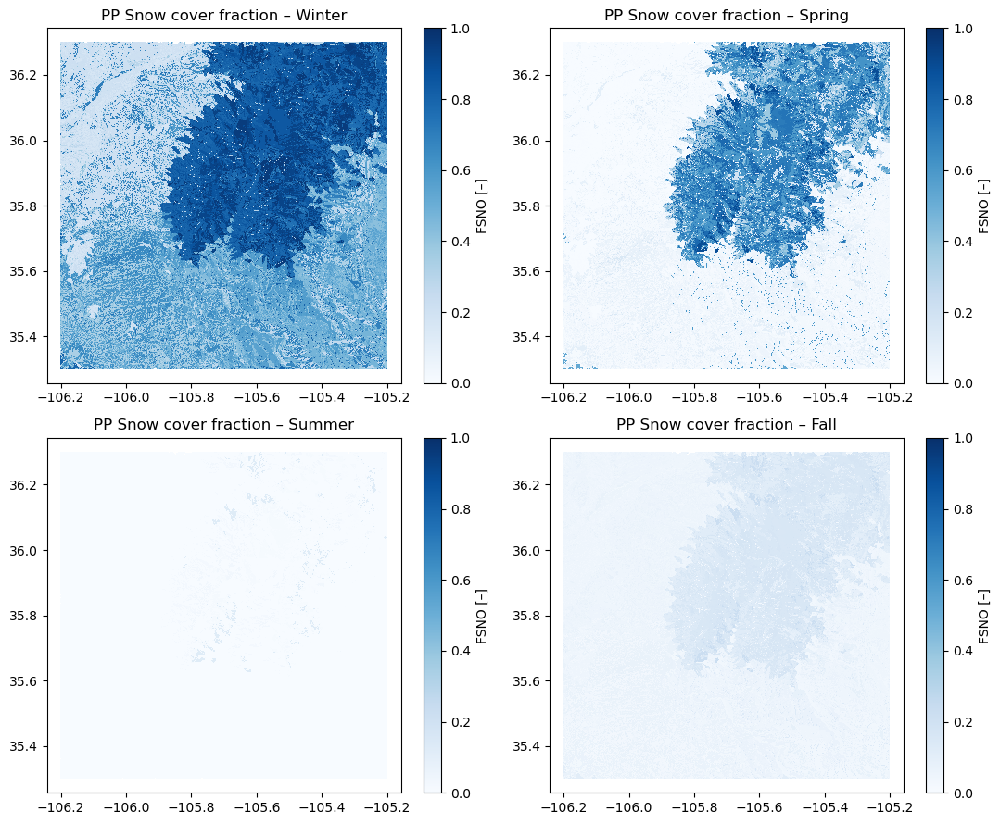

In [15]:
# snow cover fraction (fsno) seasonal plots

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# FIXED scale so that 0 is always the reference for no snow
fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

# axis corresponding to seasons
for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")       # fp - file pointer, c is the cluster which in this case is the output file (1 cluster)
        grp = fp.groups["data"]

        fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
        fp.close()              # clse file - Always good practice to free memory by closing after working with ncf file with groups and subgroups

        # Seasonal mask (boolean arrray for months)
        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        # Seasonal mean over time selection along axis=0(rows)
        data_sel = fsno[times_index, :]             # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan      # treat -9999 as invalid or mask

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]       # cropping to remove edge artifcats and keep only inner region

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="Blues",
        norm=fsno_norm,          #added: fixed 0 –1 scale
        shading="auto"
    )

    ax.set_title(f"PP Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_pp.png"),
    dpi=300
)               # dpi - dots per inch (resolution) - controls how many pixels are used per inch of the figure
plt.show()


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


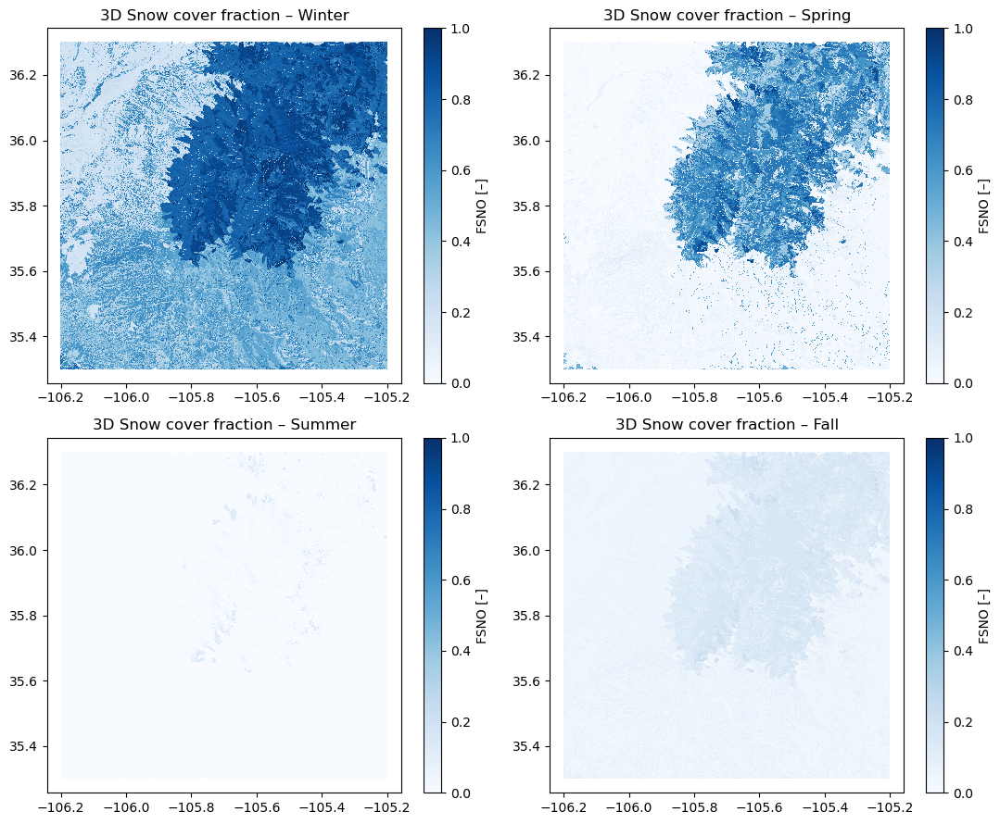

In [16]:
# 3D snow cover fraction (fsno) seasonal plots

import matplotlib.colors as colors  # <-- add if not already imported

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# FIXED scale so that 0 is always the reference for no snow
fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
        fp.close()

        # Seasonal mask
        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = fsno[times_index, :]             # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="Blues",
        norm=fsno_norm,          # fixed 0–1 scale
        shading="auto"
    )

    ax.set_title(f"3D Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_3d.png"),
    dpi=300
)
plt.show()


3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


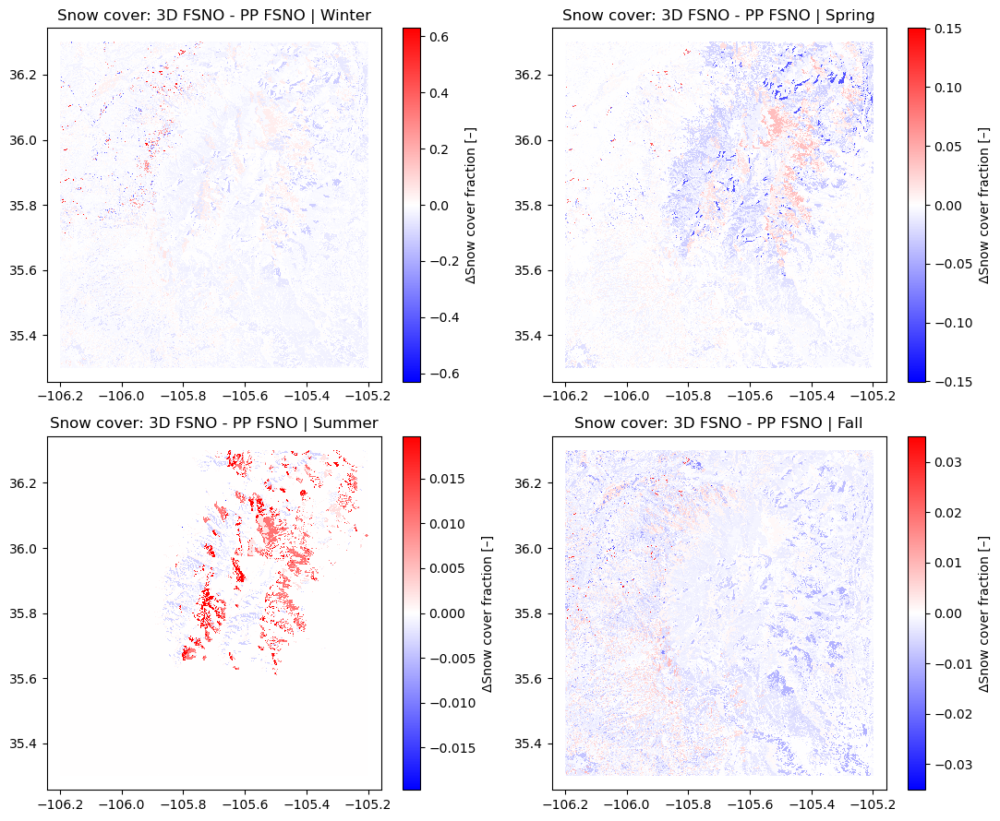

In [17]:
# 3D - PP seasonal difference maps (Snow cover fraction)
# Difference = 3D FSNO  -  PP FSNO

print("3D:", path_3d)
print("PP:", path_pp)

# use 3D domain for mapping (hrus/cids should match; we map both to the same grid)
path = path_3d

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):     #seasons (0,1,2,3)
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # seasonal mask (same for both)
    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    # ----------------------------
    # 3D seasonal mean FSNO (HRU)
    # ----------------------------
    fp_3d  = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    grp_3d = fp_3d.groups["data"]
    fsno_3d = np.array(grp_3d.variables["fsno"][:])   # (time, hru)
    fp_3d.close()

    fsno_3d_ave = np.nanmean(fsno_3d[times_index, :], axis=0)  # (hru,)
    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # ----------------------------
    # PP seasonal mean FSNO (HRU)
    # ----------------------------
    fp_pp  = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    fsno_pp = np.array(grp_pp.variables["fsno"][:])   # (time, hru)
    fp_pp.close()

    fsno_pp_ave = np.nanmean(fsno_pp[times_index, :], axis=0)  # (hru,)
    map_pp = place_data(tmp, fsno_pp_ave, hrus, cids, 1)
    map_pp = np.where(map_pp == -9999, np.nan, map_pp)

    # ----------------------------
    # remove buffer (both)
    # ----------------------------
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]

    # difference: 3D - PP
    final_map = map_3d - map_pp

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: 3D FSNO - PP FSNO | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_3D_minus_PP_FSNO_maps.png"), dpi=300)
plt.show()


3D vs PP: Winter
3D vs PP: Spring
3D vs PP: Summer
3D vs PP: Fall


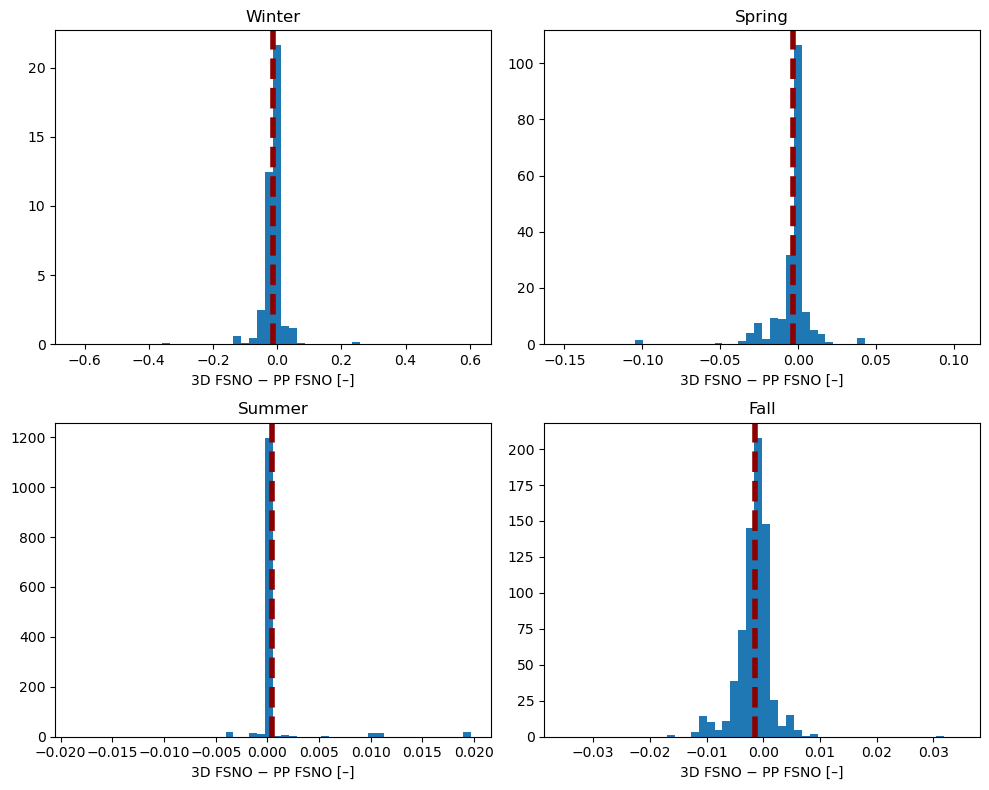

In [24]:
# 3D vs PP difference Histogram Plot (Snow cover fraction)
# Difference = 3D FSNO - PP FSNO

path_domain = path_3d  # use 3D domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"3D vs PP: {my_season}")

    # seasonal mask
    idx = times.dt.month.isin(my_months).to_numpy()

    # -------------------------
    # 3D seasonal mean FSNO (HRU)
    # -------------------------
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    fsno_3d = np.array(fp_3d.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_3d.close()
    fsno_3d_mean = np.nanmean(fsno_3d[idx, :], axis=0)

    # map 3D HRU → grid
    fsno_3d_grid = place_data(tmp, fsno_3d_mean, hrus, cids, 1)
    fsno_3d_grid = np.where(fsno_3d_grid == -9999, np.nan, fsno_3d_grid)
    fsno_3d_grid = fsno_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # PP seasonal mean FSNO (HRU)
    # -------------------------
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    fsno_pp = np.array(fp_pp.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_pp.close()
    fsno_pp_mean = np.nanmean(fsno_pp[idx, :], axis=0)

    # map PP HRU → grid (onto SAME grid)
    fsno_pp_grid = place_data(tmp, fsno_pp_mean, hrus, cids, 1)
    fsno_pp_grid = np.where(fsno_pp_grid == -9999, np.nan, fsno_pp_grid)
    fsno_pp_grid = fsno_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    diff = fsno_3d_grid - fsno_pp_grid
    arr = diff.ravel()          #Converts 2D map to 1D array
    arr = arr[np.isfinite(arr)] # remove invalid values

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D FSNO − PP FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_snow_3D_minus_PP_FSNO.png"),
    dpi=300
)
plt.show()


PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
Creating differences plot for Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2454526/312738700.py:65: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Spring
Creating differences plot for Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2454526/312738700.py:65: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Fall


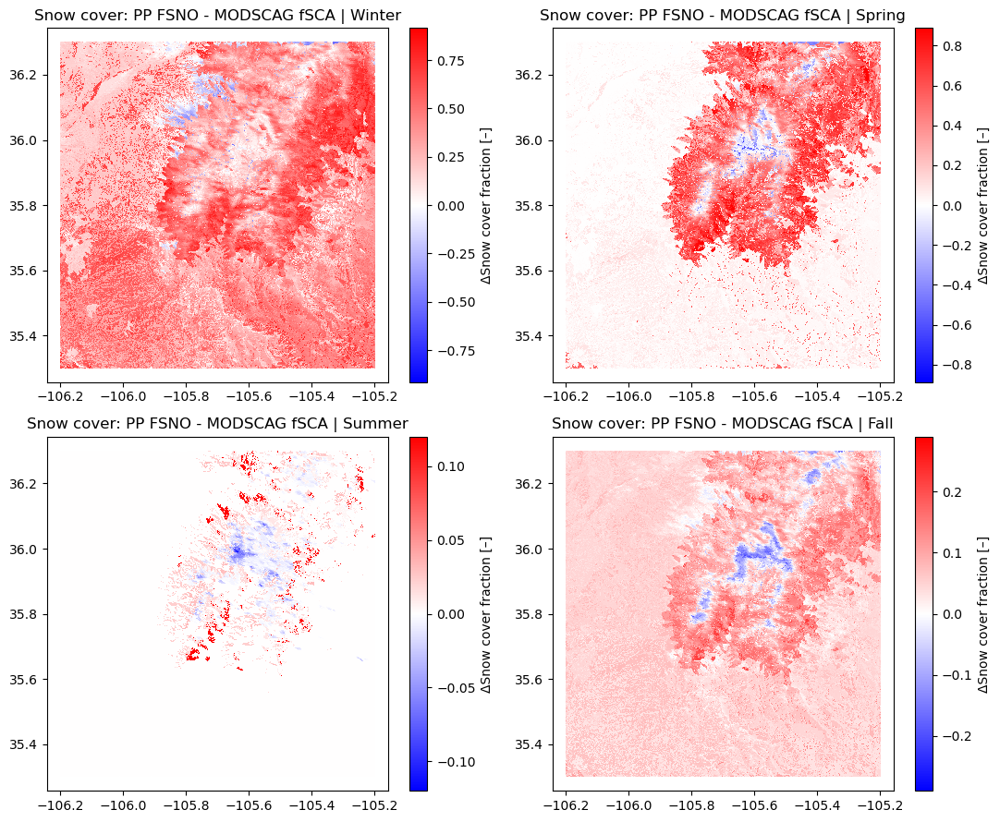

In [25]:
# PP - modscag seasonal difference maps (Snow cover fraction)
# Difference = PP FSNO  -  MODSCAG fSCA

print("PP:", path_pp)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"
print("MODSCAG:", modscag_sat)

# use PP domain for mapping
path = path_pp

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODSCAG monthly files (your filenames)
#pat = re.compile(r".*MODSCAG_HBclip_ALLVARS_(\d{4})_(\d{2})_MODELGRID_4326\.nc$")
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")  # YYYYMM

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODSCAG monthly files matched for 2016–2018 in: {modscag_folder}")
    return rows

def read_grid(fp):
    ds = xr.open_dataset(fp)

    da = ds["snow_fraction"]

    # handle fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")

    ds.close()
    return arr

def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # MODSCAG already on HydroBlocks/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modscag_rows = build_modscag_rows(modscag_sat)

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # PP model seasonal mean FSNO in HRU space
    fp_pp  = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    fsno_pp = np.array(grp_pp.variables["fsno"][:])   # (time, hru)
    fp_pp.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    fsno_pp_sel = fsno_pp[times_index, :]
    fsno_pp_ave = np.nanmean(fsno_pp_sel, axis=0)  # (hru,)

    # map model HRU -> grid
    map_pp = place_data(tmp, fsno_pp_ave, hrus, cids, 1)
    map_pp = np.ma.masked_array(map_pp, map_pp == -9999)
    map_pp[map_pp == -9999] = np.nan

    # MOODCAG seasonal mean on model grid
    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_pp.shape
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    modscag_map = modscag_map[buffer:modscag_map.shape[0]-buffer+1, buffer:modscag_map.shape[1]-buffer+1]

    # convert % -> fraction
    modscag_map = modscag_map / 100.0
    
    # difference: PP - MODSCAG
    final_map = map_pp - modscag_map

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: PP FSNO - MODSCAG fSCA | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_PP_minus_MODSCAG_fSCA_maps.png"), dpi=300)
plt.show()


modscag vs PP: Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2454526/101006637.py:15: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


modscag vs PP: Spring
modscag vs PP: Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2454526/101006637.py:15: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


modscag vs PP: Fall


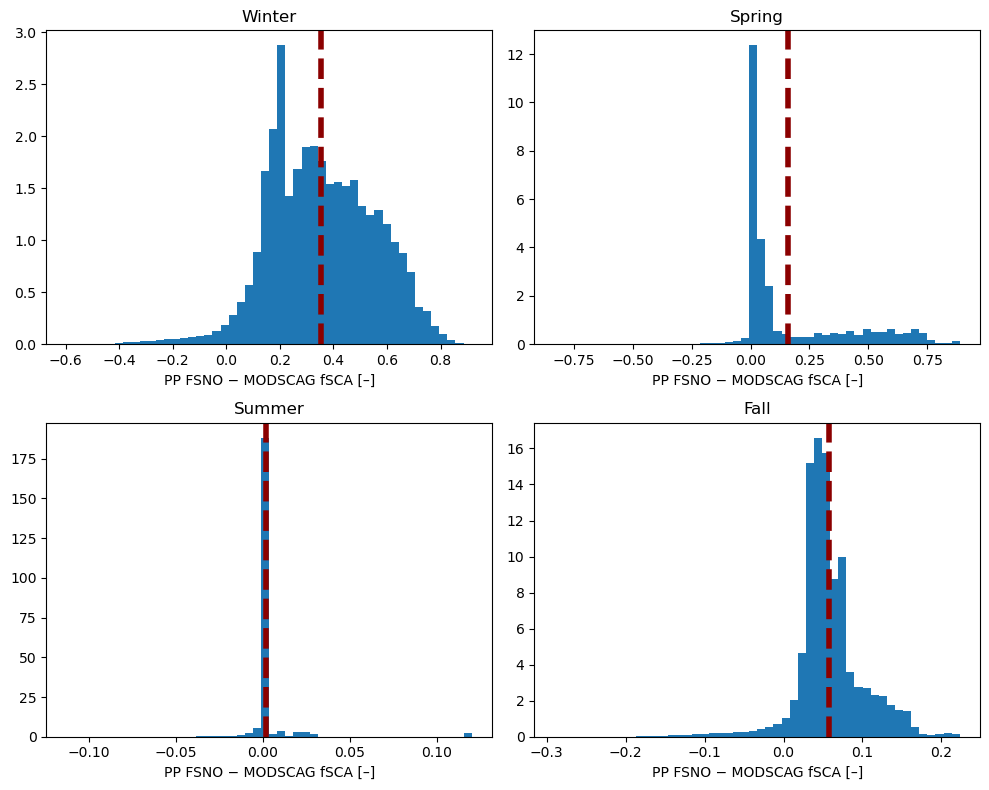

In [26]:
# PP vs MODSCAG difference Histogram Plot (Snow cover fraction)

path_domain = path_pp  # <-- changed (was path_3d)

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

def modscag_season_mean_grid(rows, months):
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months]
    if not season_arrays:
        raise RuntimeError(f"No modscag files found for months={months}")
    return np.nanmean(np.stack(season_arrays, axis=0), axis=0)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"modscag vs PP: {my_season}")  # <-- changed label

    # PP seasonal mean FSNO (HRU space)
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")  # <-- changed (was path_3d)
    fsno_pp = np.array(fp_pp.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_pp.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    fsno_pp_mean = np.nanmean(fsno_pp[idx, :], axis=0)  # <-- changed name

    # MODSCAG seasonal mean (grid, already on model grid)
    modscag_grid = modscag_season_mean_grid(modscag_rows, my_months)

    # convert percent → fraction
    modscag_grid = modscag_grid / 100.0

    modscag_grid = modscag_grid[buffer:-buffer+1, buffer:-buffer+1]

    # map PP HRU → grid
    fsno_pp_grid = place_data(tmp, fsno_pp_mean, hrus, cids, 1)  # <-- changed
    fsno_pp_grid = np.where(fsno_pp_grid == -9999, np.nan, fsno_pp_grid)
    fsno_pp_grid = fsno_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # difference
    diff = fsno_pp_grid - modscag_grid  # <-- PP - MODCAG
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    # HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed',
               linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("PP FSNO − MODSCAG fSCA [–]")  # <-- changed

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir,
                 "res_hist_snow_PP_minus_MODSCAG_fSCA.png"),  # <-- changed filename
    dpi=300
)
plt.show()


3d: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
Creating differences plot for Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2454526/4238867370.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Spring
Creating differences plot for Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2454526/4238867370.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Creating differences plot for Fall


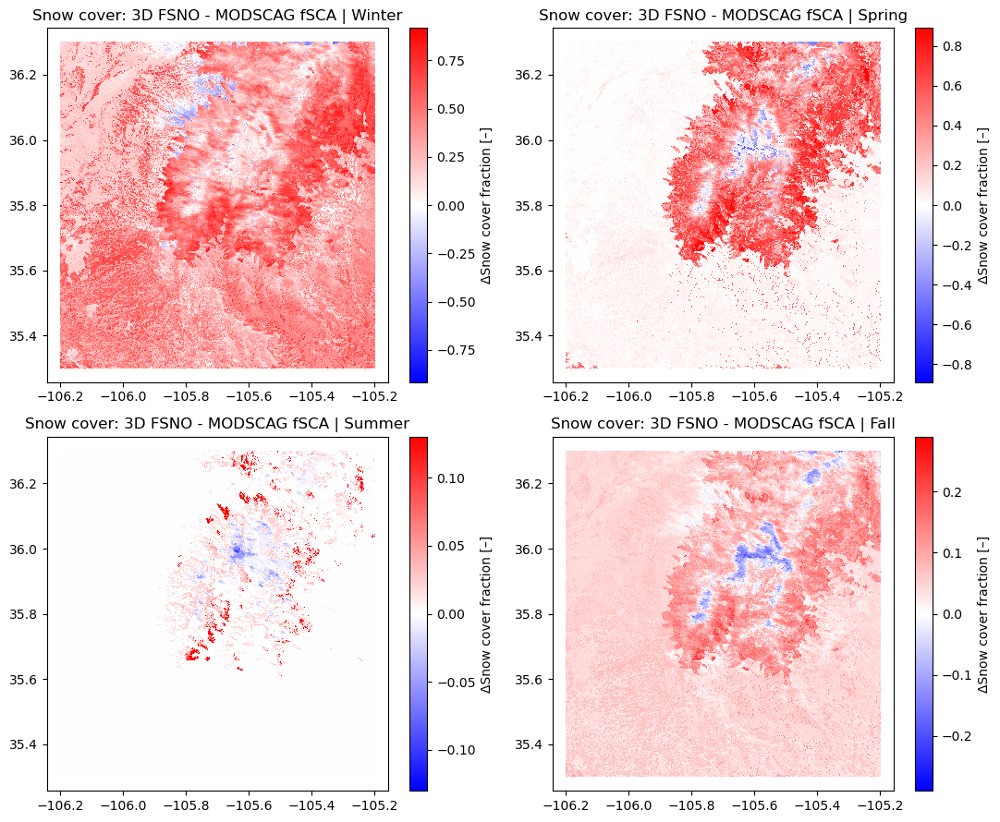

In [27]:
# 3d - modscag seasonal difference maps (Snow cover fraction)
# Difference = 3D FSNO  -  MODSCAG fSCA

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import xarray as xr

print("3d:", path_3d)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"
print("MODSCAG:", modscag_sat)

# use 3d domain for mapping
path = path_3d

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODSCAG monthly files (your filenames)
#pat = re.compile(r".*MODSCAG_HBclip_ALLVARS_(\d{4})_(\d{2})_MODELGRID_4326\.nc$")
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")  # YYYYMM

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODSCAG monthly files matched for 2016–2018 in: {modscag_folder}")
    return rows

def read_grid(fp):
    ds = xr.open_dataset(fp)

    da = ds["snow_fraction"]

    # handle fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")

    ds.close()
    return arr

def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # MODSCAG already on HydroBlocks/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modscag_rows = build_modscag_rows(modscag_sat)

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # 3d model seasonal mean FSNO in HRU space
    fp_3s  = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    grp_3d = fp_3d.groups["data"]
    fsno_3d = np.array(grp_3d.variables["fsno"][:])   # (time, hru)
    fp_3d.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    fsno_3d_sel = fsno_3d[times_index, :]
    fsno_3d_ave = np.nanmean(fsno_3d_sel, axis=0)  # (hru,)

    # map model HRU -> grid
    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = np.ma.masked_array(map_3d, map_3d == -9999)
    map_3d[map_3d == -9999] = np.nan

    # MOODCAG seasonal mean on model grid
    modscag_map = modscag_season_mean(modscag_rows, my_months)
    if modscag_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    modscag_map = modscag_map[buffer:modscag_map.shape[0]-buffer+1, buffer:modscag_map.shape[1]-buffer+1]

    # convert % -> fraction
    modscag_map = modscag_map / 100.0
    
    # difference: 3d - MODSCAG
    final_map = map_3d - modscag_map

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: 3D FSNO - MODSCAG fSCA | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_3d_minus_MODSCAG_fSCA_maps.png"), dpi=300)
plt.show()


modscag vs 3d: Winter


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2454526/2545703539.py:15: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


modscag vs 3d: Spring
modscag vs 3d: Summer


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2454526/2545703539.py:15: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(season_arrays, axis=0), axis=0)


modscag vs 3d: Fall


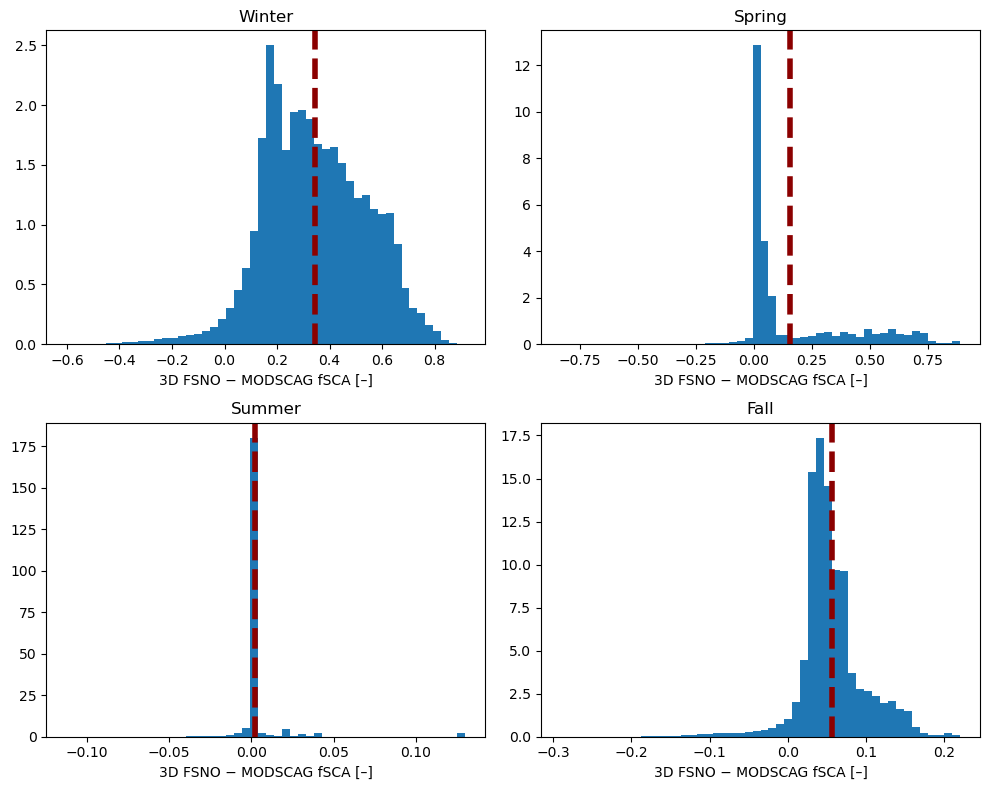

In [28]:
# 3D vs MODSCAG difference Histogram Plot (Snow cover fraction)

path_domain = path_3d  # <-- changed (was path_3d)

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

def modscag_season_mean_grid(rows, months):
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months]
    if not season_arrays:
        raise RuntimeError(f"No modscag files found for months={months}")
    return np.nanmean(np.stack(season_arrays, axis=0), axis=0)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"modscag vs 3d: {my_season}")  # <-- changed label

    # 3d seasonal mean FSNO (HRU space)
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")  # <-- changed (was path_3d)
    fsno_3d = np.array(fp_3d.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_3d.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    fsno_3d_mean = np.nanmean(fsno_3d[idx, :], axis=0)  # <-- changed name

    # MODSCAG seasonal mean (grid, already on model grid)
    modscag_grid = modscag_season_mean_grid(modscag_rows, my_months)

    # convert percent → fraction
    modscag_grid = modscag_grid / 100.0

    modscag_grid = modscag_grid[buffer:-buffer+1, buffer:-buffer+1]

    # map 3d HRU → grid
    fsno_3d_grid = place_data(tmp, fsno_3d_mean, hrus, cids, 1)  # <-- changed
    fsno_3d_grid = np.where(fsno_3d_grid == -9999, np.nan, fsno_3d_grid)
    fsno_3d_grid = fsno_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # difference
    diff = fsno_3d_grid - modscag_grid  # <-- 3D - MODSCAG
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    # HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed',
               linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D FSNO − MODSCAG fSCA [–]")  # <-- changed

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir,
                 "res_hist_snow_3D_minus_MODSCAG_fSCA.png"),  # <-- changed filename
    dpi=300
)
plt.show()


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/1465797900.py:62: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/1465797900.py:62: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


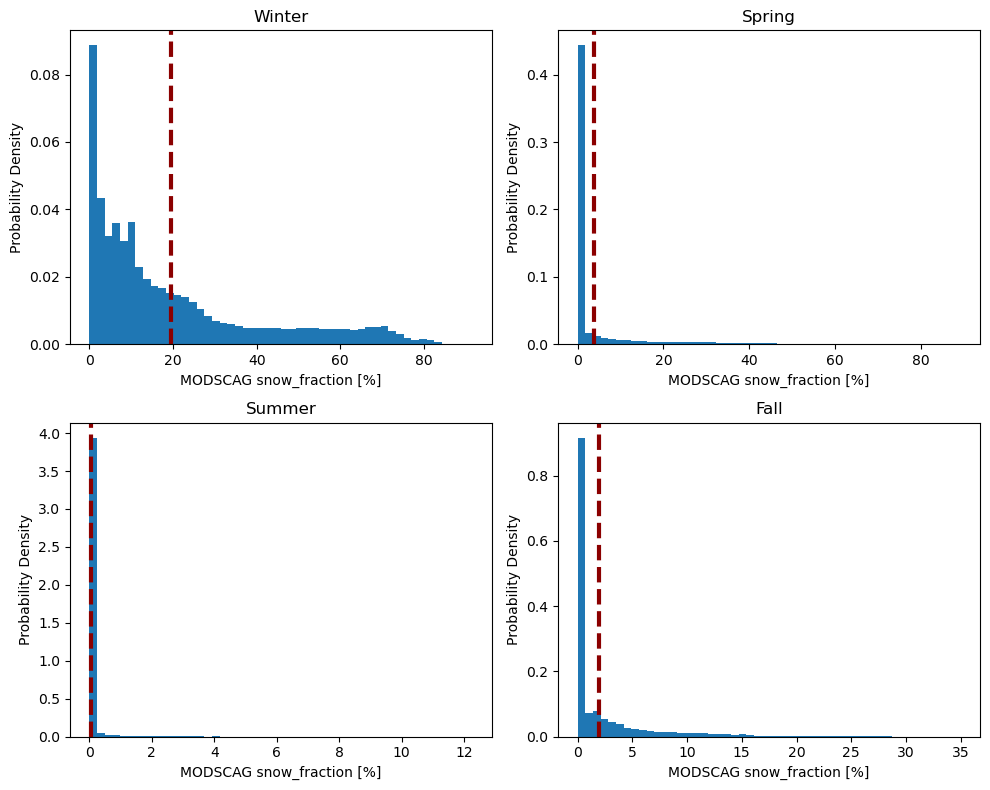

In [26]:
import os
import glob, re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# INPUT folder (same as your script)
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

# OUTPUT folder
try:
    outputdir
except NameError:
    outputdir = modscag_sat
os.makedirs(outputdir, exist_ok=True)

# File pattern (same as your script)
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")  # YYYYMM

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        if yyyy < 2016 or yyyy > 2018:
            continue
        rows.append((pd.Timestamp(yyyy, mm, 1), fp))
    rows.sort(key=lambda x: x[0])
    return rows

def read_snow_fraction(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]
    da = da.where(da != 255).where(da != -9999)  # remove fill values
    arr = da.values.astype("float32")
    ds.close()
    return arr

def read_grid(fp):
    # Read MODSCAG snow_fraction from the monthly NetCDF on HB grid
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    # handle common fill values (MODSCAG original fill is 255; your processing may also use -9999)
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")

    ds.close()
    return arr

def modscag_season_mean(rows, months):
    arrs = [read_snow_fraction(fp) for dt, fp in rows if dt.month in months]
    if not arrs:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

# --- seasonal histograms ---
import pandas as pd  # needed for Timestamp above

rows = build_modscag_rows(modscag_sat)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, months) in enumerate(zip(seasons, season_months)):
    season_map = modscag_season_mean(rows, months)
    if season_map is None:
        axes[i].axis("off")
        continue

    arr = season_map.ravel()
    arr = arr[np.isfinite(arr)]

    axes[i].hist(arr, bins=50, density=True)
    axes[i].axvline(np.mean(arr), linestyle="dashed", linewidth=3, color="darkred")
    axes[i].set_title(name)
    axes[i].set_xlabel("MODSCAG snow_fraction [%]")
    axes[i].set_ylabel("Probability Density")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_hist_MODSCAG_snow_fraction_seasonal.png"), dpi=300)
plt.show()

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


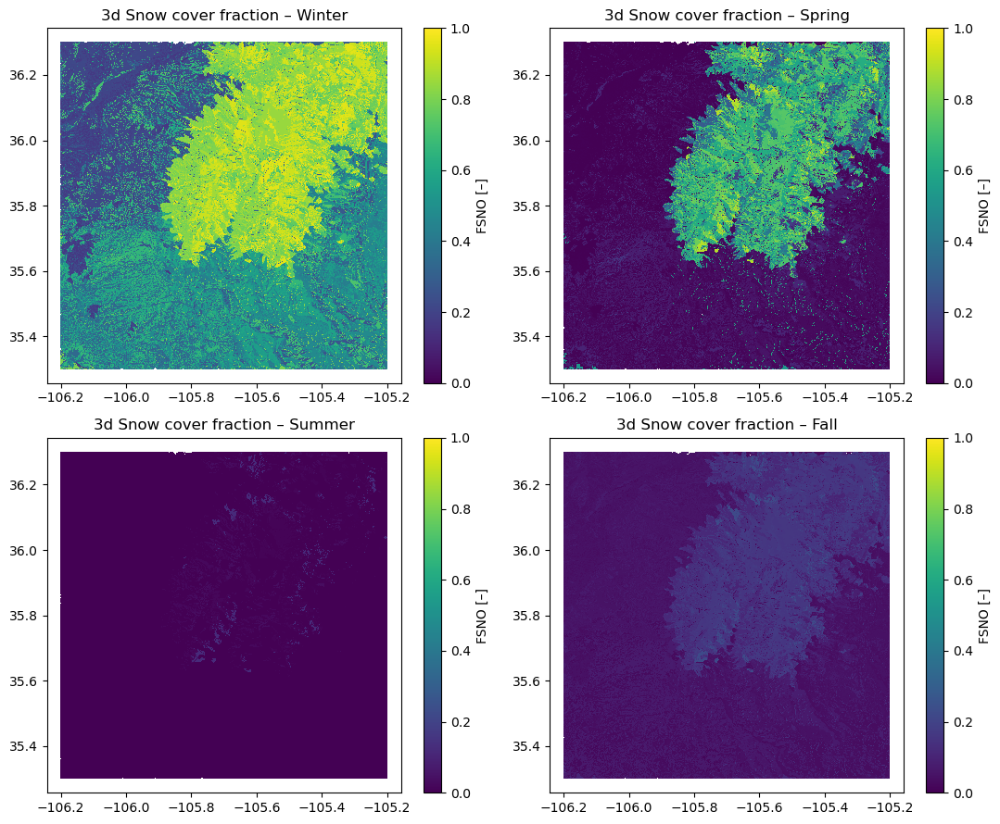

In [27]:
# snow cover fraction (fsno) seasonal plots

import matplotlib.colors as colors

#path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_2/MSWX_3h_Snow_Project3_pp/"
#path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MFSNO_SCALE_PARAMETER/MSWX_3h_Snow_Project3_3d_para7/'
path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
        nt = fsno.shape[0]
        fp.close()

        # build matching datetime vector for THIS variable length
        start = pd.Timestamp("2016-01-01 00:00")
        times_local = pd.Series(
            (start + pd.to_timedelta(np.arange(nt) * 3, unit="h"))
            .tz_localize("UTC")
            .tz_convert("America/Denver"),
            name="datetime"
        )

        # Seasonal mask
        times_index = (
            (times_local.dt.month == my_months[0]) |
            (times_local.dt.month == my_months[1]) |
            (times_local.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = fsno[times_index.values, :]      # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # fresh template each loop
        tmp = np.copy(hrus)
        tmp[:] = -9999.0

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map = final_map.astype(float)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"3d Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_pp.png"),
    dpi=300
)
plt.show()

In [28]:
import netCDF4 as nc


import netCDF4 as nc
import os

#base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_2/MSWX_3h_Snow_Project3_pp/"
base = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/'
cid = 1
input_file = os.path.join(base, f"{cid}/input_file.nc")
output_file = os.path.join(base, f"output_data/{cid}/2016-01-01.nc")

def list_nc_vars(path):
    print(f"\n--- File: {path} ---")
    with nc.Dataset(path) as ds:
        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(f"  {vname:20s} shape={var.shape} dims={var.dimensions}")

# Inspect static (parameters/meteorology)
list_nc_vars(input_file)

# Inspect dynamic outputs
list_nc_vars(output_file)



--- File: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/1/input_file.nc ---

[Group: meteorology]
  lwdown               shape=(8744, 1000) dims=('time', 'hru')
  swdown               shape=(8744, 1000) dims=('time', 'hru')
  tair                 shape=(8744, 1000) dims=('time', 'hru')
  precip               shape=(8744, 1000) dims=('time', 'hru')
  psurf                shape=(8744, 1000) dims=('time', 'hru')
  wind                 shape=(8744, 1000) dims=('time', 'hru')
  spfh                 shape=(8744, 1000) dims=('time', 'hru')
  time                 shape=(8744,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                 shape=(4,) dims=('connections_columns',)
  indices              shape=(4,) dims=('connections_columns',)
  indptr               shape=(3,) dims=('connections_rows',)

[Group: wmatrix_Basin2]
  data                 shape=(4,) dims=('connections_columns',)
  i

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


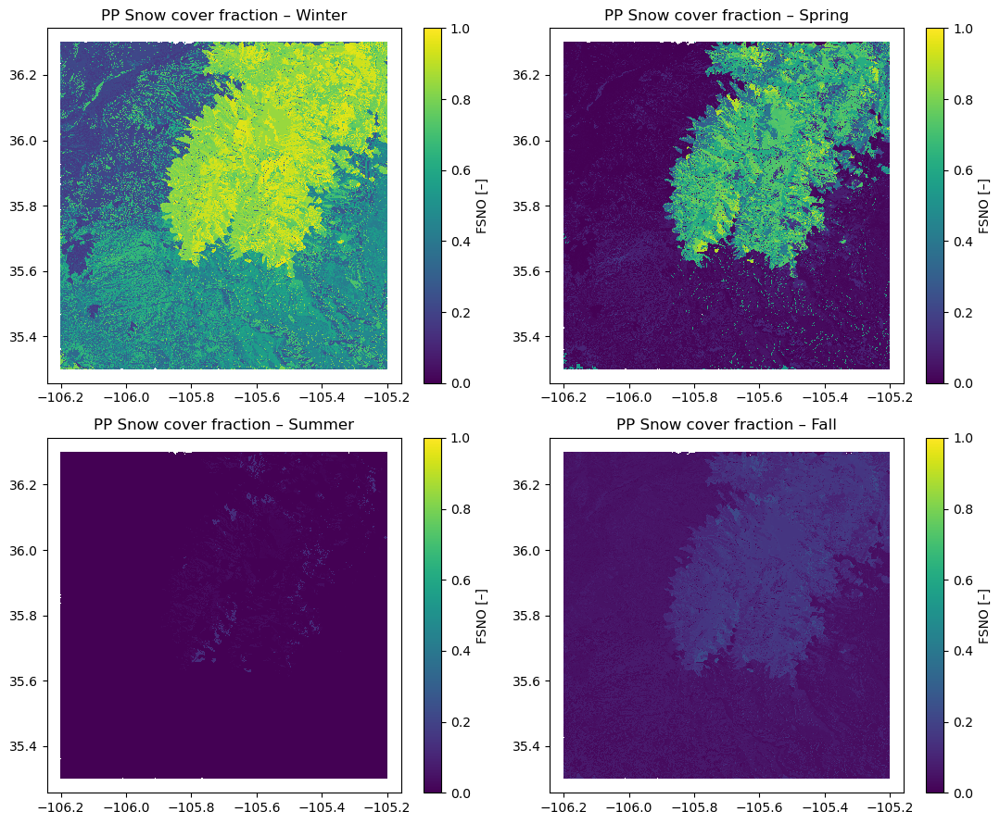

In [29]:
# snow cover fraction (fsno) seasonal plots

import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus).astype(float)
tmp[:] = -9999.0

# If not already defined earlier
buffer = 250
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

# -----------------------------
# Read output file once
# -----------------------------
fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
grp = fp.groups["data"]

fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
nt = fsno.shape[0]

fp.close()

# -----------------------------
# Build matching time vector
# -----------------------------
# Use the known start and 3-hourly timestep
start = pd.Timestamp("2016-01-01 00:00")
times = pd.date_range(start=start, periods=nt, freq="3H")

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    times_index = (
        (times.month == my_months[0]) |
        (times.month == my_months[1]) |
        (times.month == my_months[2])
    )

    data_sel = fsno[times_index, :]          # (time, hru)
    data_ave = np.nanmean(data_sel, axis=0)  # (hru,)

    final_map = place_data(tmp, data_ave, hrus, cids, 1)

    final_map = np.ma.masked_where(final_map == -9999.0, final_map)

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        norm=fsno_norm,
        shading="auto"
    )

    ax.set_title(f"PP Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal_pp_viridis_cmap.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [30]:
import os
import glob
import re
import pandas as pd

modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"

pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")

files = sorted(glob.glob(os.path.join(modscag_sat, "*.nc")))

dates = []
for f in files:
    name = os.path.basename(f)
    m = pat.match(name)
    if m:
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm   = int(yyyymm[4:])
        dates.append(pd.Timestamp(yyyy, mm, 1))

# Convert to dataframe for easy summary
df = pd.DataFrame({"date": dates})
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print("Total files:", len(df))
print("\nYears available:")
print(sorted(df["year"].unique()))

print("\nCounts per year:")
print(df.groupby("year").size())

print("\nCheck missing months per year:")
for y in sorted(df["year"].unique()):
    months = sorted(df[df["year"] == y]["month"].unique())
    missing = sorted(set(range(1,13)) - set(months))
    print(f"{y}: months={months} | missing={missing}")

Total files: 36

Years available:
[2016, 2017, 2018]

Counts per year:
year
2016    12
2017    12
2018    12
dtype: int64

Check missing months per year:
2016: months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] | missing=[]
2017: months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] | missing=[]
2018: months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] | missing=[]


In [31]:
import netCDF4 as nc
import pandas as pd
import numpy as np

fp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
grp = fp.groups["data"]

# check one variable shape
fsno = np.array(grp.variables["fsno"][:])
fp.close()

ntime = fsno.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

print("ntime =", ntime)
print("start =", times.min())
print("end   =", times.max())
print("years =", sorted(pd.Index(times.year).unique()))

ntime = 8744
start = 2016-01-01 00:00:00
end   = 2018-12-28 21:00:00
years = [2016, 2017, 2018]


PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/
3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d/
MODSCAG: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL
Output: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/971452023.py:125: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


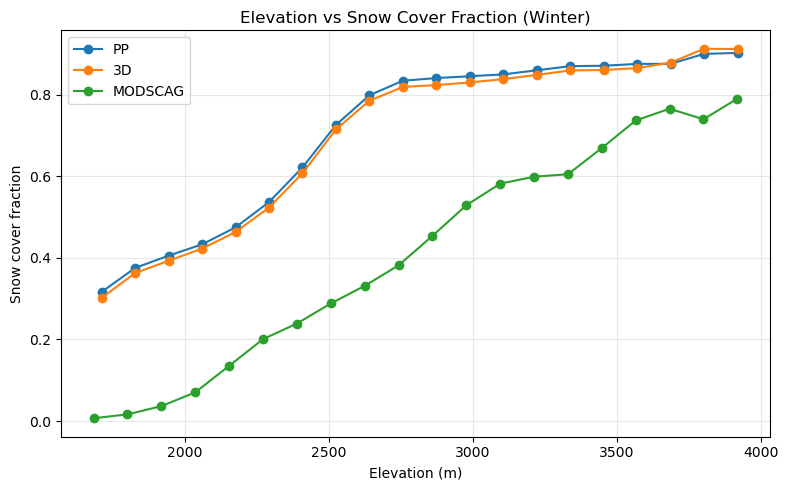

In [32]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import os, glob, re
import xarray as xr
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# PATHS
# ----------------------------

path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/'
path_3d = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d/'
modscag_sat = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"

os.makedirs(outputdir, exist_ok=True)

print("PP:", path_pp)
print("3D:", path_3d)
print("MODSCAG:", modscag_sat)
print("Output:", outputdir)

# ----------------------------
# READ TIME FROM INPUT FILE
# ----------------------------
fp = nc.Dataset(path_3d + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

start = pd.Timestamp("2016-01-01 00:00:00")
times = start + pd.to_timedelta(time, unit="h")
times = pd.DatetimeIndex(times).tz_localize("UTC").tz_convert("America/Denver")

# ----------------------------
# READ HRU / CID / DEM FROM ONE CONSISTENT GRID
# use PP grid as reference
# ----------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")
dem  = gdal_tools.read_raster(path_pp + "postprocess/dem.vrt")

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

# trim DEM to buffered domain
dem = dem[buffer:dem.shape[0]-buffer+1, buffer:dem.shape[1]-buffer+1]

# ----------------------------
# HELPER FUNCTIONS
# ----------------------------
def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out


# MODSCAG filenames like: MODSCAG_HBclip_ALLVARS_201601_MODELGRID_4326.nc
pat = re.compile(r"MODSCAG_HBclip_ALLVARS_(\d{6})_MODELGRID_4326\.nc$")

def build_modscag_rows(modscag_folder):
    files = sorted(glob.glob(os.path.join(modscag_folder, "*.nc")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        yyyy = int(yyyymm[:4])
        mm = int(yyyymm[4:])
        dt = pd.Timestamp(yyyy, mm, 1)

        # keep only 2016–2018 to match your current analysis period
        if dt.year < 2016 or dt.year > 2018:
            continue

        rows.append((dt, fp))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError(f"No MODSCAG monthly files found in {modscag_folder}")

    return rows


def read_modscag_grid(fp):
    ds = xr.open_dataset(fp)
    da = ds["snow_fraction"]

    # handle fill values
    da = da.where(da != 255)
    da = da.where(da != -9999)

    arr = da.values.astype("float32")
    ds.close()
    return arr


def modscag_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_modscag_grid(fp))

    if len(arrs) == 0:
        return None

    return np.nanmean(np.stack(arrs, axis=0), axis=0)


def get_fsno_map(path_model, months):
    fp = nc.Dataset(path_model + "output_data/1/2016-01-01.nc")
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()

    month_vals = pd.to_datetime(times).month

    idx = ((month_vals == months[0]) |
           (month_vals == months[1]) |
           (month_vals == months[2]))

    fsno_sel = fsno[idx, :]
    fsno_avg = np.nanmean(fsno_sel, axis=0)

    map_out = place_data(tmp, fsno_avg, hrus, cids, 1)
    map_out = np.array(map_out, dtype=np.float32)
    map_out[map_out == -9999] = np.nan

    map_out = map_out[buffer:map_out.shape[0]-buffer+1,
                      buffer:map_out.shape[1]-buffer+1]

    return map_out


def elevation_profile(elev, snow, bins=20):
    mask = np.isfinite(elev) & np.isfinite(snow)

    elev_vals = elev[mask]
    snow_vals = snow[mask]

    bin_edges = np.linspace(np.nanmin(elev_vals), np.nanmax(elev_vals), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    means = []
    for i in range(bins):
        # include upper edge in last bin
        if i < bins - 1:
            idx = (elev_vals >= bin_edges[i]) & (elev_vals < bin_edges[i+1])
        else:
            idx = (elev_vals >= bin_edges[i]) & (elev_vals <= bin_edges[i+1])

        if np.sum(idx) > 0:
            means.append(np.nanmean(snow_vals[idx]))
        else:
            means.append(np.nan)

    return bin_centers, np.array(means)


# ----------------------------
# BUILD MODSCAG FILE LIST
# ----------------------------
modscag_rows = build_modscag_rows(modscag_sat)

# ----------------------------
# CHOOSE SEASON
# ----------------------------
months = (12, 1, 2)   # Winter

# ----------------------------
# GET MAPS
# ----------------------------
pp_map = get_fsno_map(path_pp, months)
map_3d = get_fsno_map(path_3d, months)
mod_map = modscag_season_mean(modscag_rows, months)

if mod_map is None:
    raise RuntimeError("No MODSCAG seasonal map could be created for selected months.")

# trim MODSCAG to same buffered domain
mod_map = mod_map[buffer:mod_map.shape[0]-buffer+1,
                  buffer:mod_map.shape[1]-buffer+1]

# convert MODSCAG percent -> fraction
mod_map = mod_map / 100.0

# ----------------------------
# ELEVATION PROFILES
# ----------------------------
elev_pp,  prof_pp  = elevation_profile(dem, pp_map, bins=20)
elev_3d,  prof_3d  = elevation_profile(dem, map_3d, bins=20)
elev_mod, prof_mod = elevation_profile(dem, mod_map, bins=20)

# ----------------------------
# COMBINED PLOT
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(elev_pp, prof_pp, "-o", label="PP")
plt.plot(elev_3d, prof_3d, "-o", label="3D")
plt.plot(elev_mod, prof_mod, "-o", label="MODSCAG")

plt.xlabel("Elevation (m)")
plt.ylabel("Snow cover fraction")
plt.title("Elevation vs Snow Cover Fraction (Winter)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputdir, "elevation_vs_fsno_combined.png"), dpi=300)
plt.show()

Processing Winter ...


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/971452023.py:125: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing Spring ...
Processing Summer ...


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/971452023.py:125: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing Fall ...


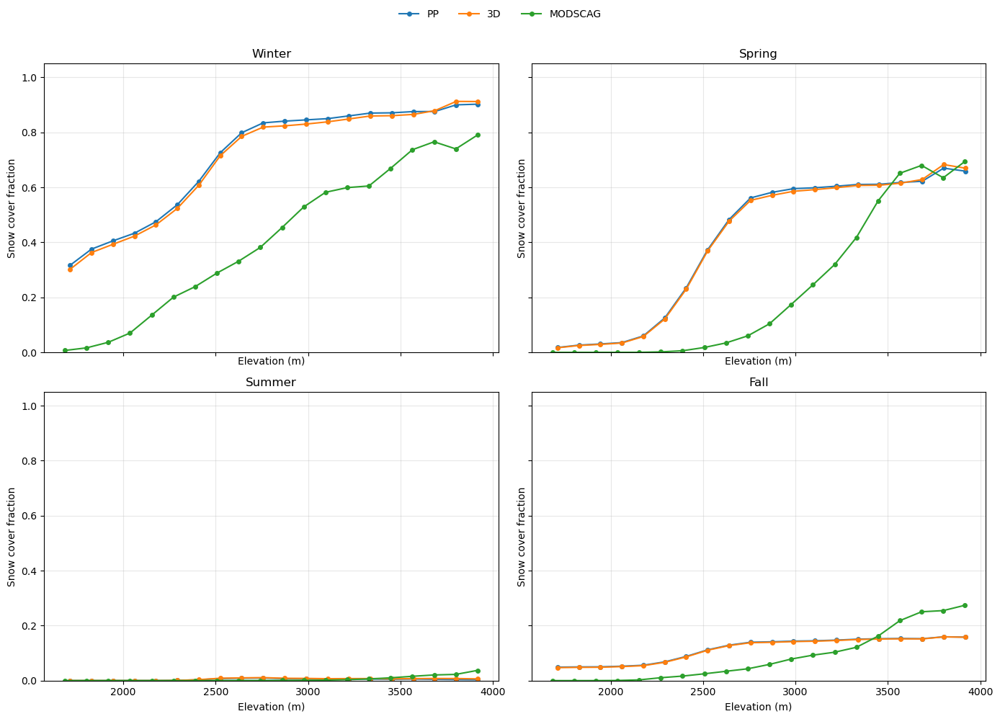

In [33]:
# ----------------------------
# PLOT ALL SEASONS: 2 x 2 GRID
# each panel shows PP, 3D, MODSCAG
# ----------------------------
season_dict = {
    "Winter": (12, 1, 2),
    "Spring": (3, 4, 5),
    "Summer": (6, 7, 8),
    "Fall":   (9, 10, 11),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (season_name, months) in zip(axes, season_dict.items()):
    print(f"Processing {season_name} ...")

    # get seasonal maps
    pp_map = get_fsno_map(path_pp, months)
    map_3d = get_fsno_map(path_3d, months)
    mod_map = modscag_season_mean(modscag_rows, months)

    if mod_map is None:
        ax.set_title(f"{season_name} (no MODSCAG data)")
        ax.axis("off")
        continue

    # trim MODSCAG to same buffered domain
    mod_map = mod_map[buffer:mod_map.shape[0]-buffer+1,
                      buffer:mod_map.shape[1]-buffer+1]

    # convert MODSCAG percent -> fraction
    mod_map = mod_map / 100.0

    # elevation profiles
    elev_pp,  prof_pp  = elevation_profile(dem, pp_map, bins=20)
    elev_3d,  prof_3d  = elevation_profile(dem, map_3d, bins=20)
    elev_mod, prof_mod = elevation_profile(dem, mod_map, bins=20)

    # plot all 3 curves in each season
    ax.plot(elev_pp,  prof_pp,  "-o", label="PP", markersize=4)
    ax.plot(elev_3d,  prof_3d,  "-o", label="3D", markersize=4)
    ax.plot(elev_mod, prof_mod, "-o", label="MODSCAG", markersize=4)

    ax.set_title(season_name)
    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("Snow cover fraction")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(outputdir, "elevation_vs_fsno_all_seasons_2x2.png"), dpi=300)
plt.show()

Processing Winter ...


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/971452023.py:125: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing Spring ...
Processing Summer ...


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/971452023.py:125: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing Fall ...


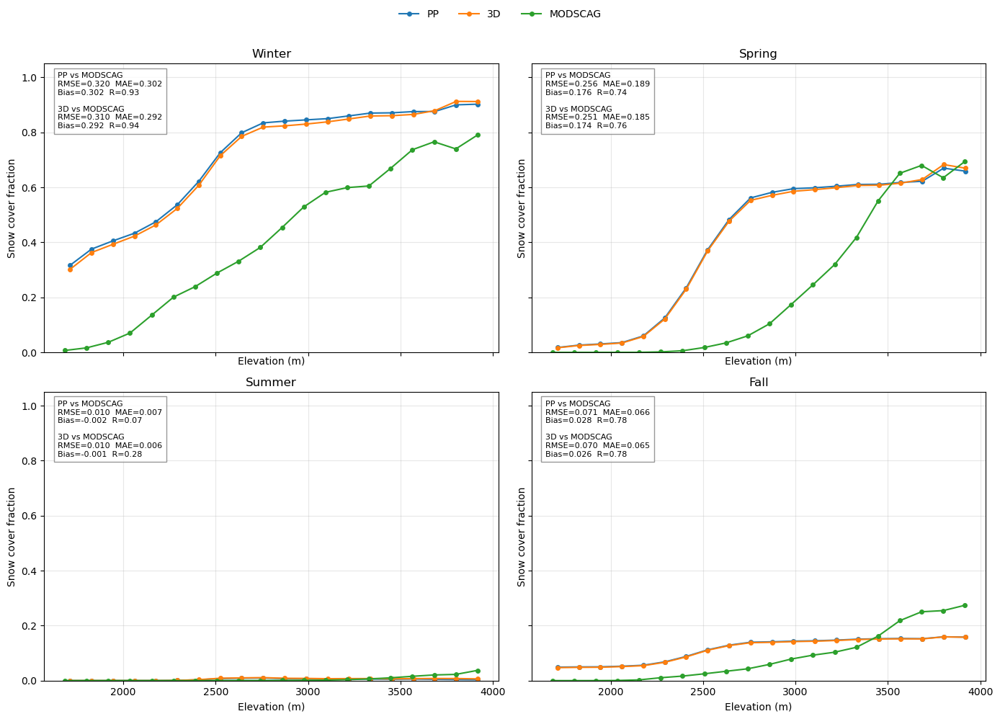

In [34]:
# Seasonal plot of fsno with errors estimations

def compute_profile_metrics(model_prof, obs_prof):
    mask = np.isfinite(model_prof) & np.isfinite(obs_prof)

    if np.sum(mask) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "Bias": np.nan, "R": np.nan}

    m = model_prof[mask]
    o = obs_prof[mask]

    rmse = np.sqrt(np.mean((m - o) ** 2))
    mae  = np.mean(np.abs(m - o))
    bias = np.mean(m - o)

    if len(m) > 1:
        r = np.corrcoef(m, o)[0, 1]
    else:
        r = np.nan

    return {"RMSE": rmse, "MAE": mae, "Bias": bias, "R": r}

    # ----------------------------
# PLOT ALL SEASONS: 2 x 2 GRID
# each panel shows PP, 3D, MODSCAG
# with error metrics vs MODSCAG
# ----------------------------
season_dict = {
    "Winter": (12, 1, 2),
    "Spring": (3, 4, 5),
    "Summer": (6, 7, 8),
    "Fall":   (9, 10, 11),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (season_name, months) in zip(axes, season_dict.items()):
    print(f"Processing {season_name} ...")

    # get seasonal maps
    pp_map = get_fsno_map(path_pp, months)
    map_3d = get_fsno_map(path_3d, months)
    mod_map = modscag_season_mean(modscag_rows, months)

    if mod_map is None:
        ax.set_title(f"{season_name} (no MODSCAG data)")
        ax.axis("off")
        continue
        
    
    # trim MODSCAG to same buffered domain
    mod_map = mod_map[buffer:mod_map.shape[0]-buffer+1,
                      buffer:mod_map.shape[1]-buffer+1]

    # convert MODSCAG percent -> fraction
    mod_map = mod_map / 100.0

    # elevation profiles
    elev_pp,  prof_pp  = elevation_profile(dem, pp_map, bins=20)
    elev_3d,  prof_3d  = elevation_profile(dem, map_3d, bins=20)
    elev_mod, prof_mod = elevation_profile(dem, mod_map, bins=20)

    # metrics against MODSCAG
    met_pp = compute_profile_metrics(prof_pp, prof_mod)
    met_3d = compute_profile_metrics(prof_3d, prof_mod)

    # plot all 3 curves in each season
    ax.plot(elev_pp,  prof_pp,  "-o", label="PP", markersize=4)
    ax.plot(elev_3d,  prof_3d,  "-o", label="3D", markersize=4)
    ax.plot(elev_mod, prof_mod, "-o", label="MODSCAG", markersize=4)

    ax.set_title(season_name)
    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("Snow cover fraction")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # add metrics text box
    txt = (
        f"PP vs MODSCAG\n"
        f"RMSE={met_pp['RMSE']:.3f}  MAE={met_pp['MAE']:.3f}\n"
        f"Bias={met_pp['Bias']:.3f}  R={met_pp['R']:.2f}\n"
        f"\n"
        f"3D vs MODSCAG\n"
        f"RMSE={met_3d['RMSE']:.3f}  MAE={met_3d['MAE']:.3f}\n"
        f"Bias={met_3d['Bias']:.3f}  R={met_3d['R']:.2f}"
    )

    ax.text(
        0.03, 0.97, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(outputdir, "elevation_vs_fsno_all_seasons_2x2_with_metrics.png"), dpi=300)
plt.show()

In [36]:
print("PP:", np.nanmin(pp_map), np.nanmax(pp_map), np.nanmean(pp_map))
print("MODSCAG (raw):", np.nanmin(mod_map), np.nanmax(mod_map), np.nanmean(mod_map))
print("MODSCAG (flipped):", np.nanmin(np.flipud(mod_map)), np.nanmax(np.flipud(mod_map)), np.nanmean(np.flipud(mod_map)))

PP: 0.014509985 0.22326075 0.08161434
MODSCAG (raw): 0.0 0.35001433 0.022397954
MODSCAG (flipped): 0.0 0.35001433 0.022397945


In [37]:
mask = np.isfinite(pp_map) & np.isfinite(mod_map)

corr_raw  = np.corrcoef(pp_map[mask], mod_map[mask])[0,1]
corr_flip = np.corrcoef(pp_map[mask], np.flipud(mod_map)[mask])[0,1]

print("corr raw :", corr_raw)
print("corr flip:", corr_flip)

corr raw : 0.048602317140244634
corr flip: 0.600677237413773


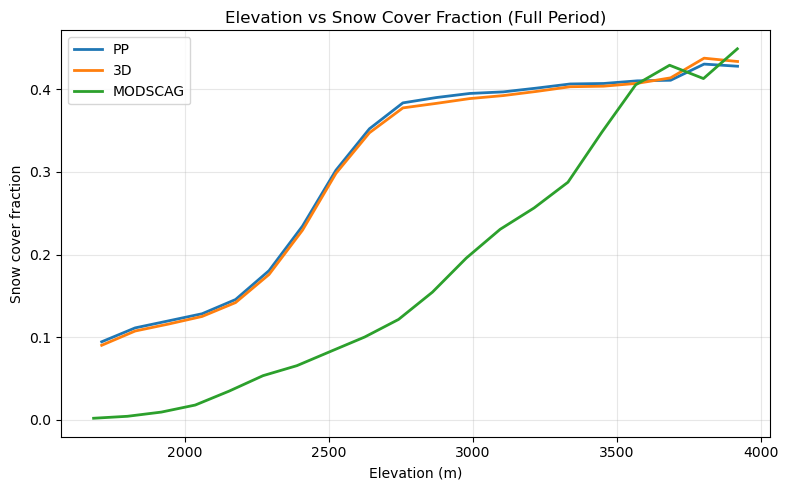

In [38]:
# ----------------------------
# FULL-PERIOD ELEVATION vs FSNO
# PP, 3D, MODSCAG on same plot
# ----------------------------

def get_fsno_map_fullperiod(path_model):
    fp = nc.Dataset(path_model + "output_data/1/2016-01-01.nc")
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()

    # mean over all time steps
    fsno_avg = np.nanmean(fsno, axis=0)

    # map HRU -> grid
    map_out = place_data(tmp, fsno_avg, hrus, cids, 1)
    map_out = np.array(map_out, dtype=np.float32)
    map_out[map_out == -9999] = np.nan

    # trim buffer
    map_out = map_out[buffer:map_out.shape[0]-buffer+1,
                      buffer:map_out.shape[1]-buffer+1]

    return map_out


def modscag_fullperiod_mean(rows):
    arrs = []
    for dt, fp in rows:
        arr = read_modscag_grid(fp)
        arr = arr.astype(np.float32)

        # trim buffer
        arr = arr[buffer:arr.shape[0]-buffer+1,
                  buffer:arr.shape[1]-buffer+1]

        # convert percent -> fraction
        arr = arr / 100.0

        arrs.append(arr)

    if len(arrs) == 0:
        return None

    return np.nanmean(np.stack(arrs, axis=0), axis=0)


# get full-period maps
pp_map  = get_fsno_map_fullperiod(path_pp)
map_3d  = get_fsno_map_fullperiod(path_3d)
mod_map = modscag_fullperiod_mean(modscag_rows)

if mod_map is None:
    raise RuntimeError("No MODSCAG data found for full-period mean.")

# elevation profiles
elev_pp,  prof_pp  = elevation_profile(dem, pp_map, bins=20)
elev_3d,  prof_3d  = elevation_profile(dem, map_3d, bins=20)
elev_mod, prof_mod = elevation_profile(dem, mod_map, bins=20)

# plot all three together
plt.figure(figsize=(8, 5))
plt.plot(elev_pp,  prof_pp,  "-", linewidth=2, label="PP")
plt.plot(elev_3d,  prof_3d,  "-", linewidth=2, label="3D")
plt.plot(elev_mod, prof_mod, "-", linewidth=2, label="MODSCAG")

plt.xlabel("Elevation (m)")
plt.ylabel("Snow cover fraction")
plt.title("Elevation vs Snow Cover Fraction (Full Period)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputdir, "elevation_vs_fsno_fullperiod.png"), dpi=300)
plt.show()

MSWX fsno shape : (8744, 1000)
NLDAS fsno shape: (8744, 1000)
MSWX hrus shape : (1801, 1801)
NLDAS hrus shape: (1801, 1801)
Same plotting grid: True


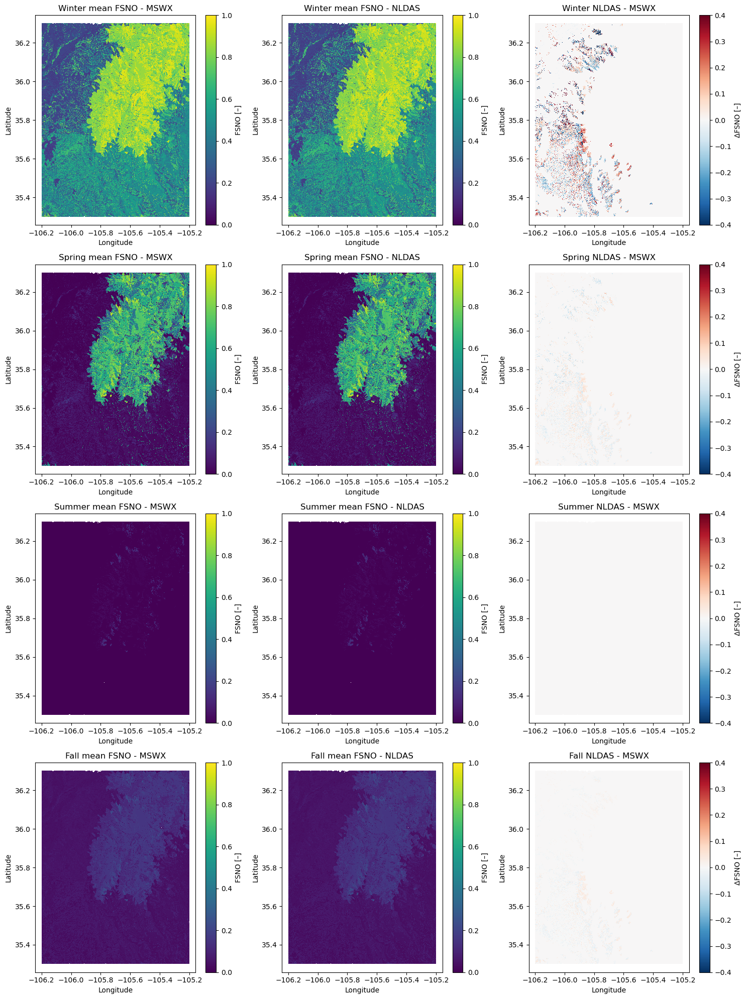

In [39]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# Paths
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/"
path_nldas = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# clean 2016 file
file_mswx  = path_mswx  + "output_data/1/2016-01-01.nc"
file_nldas = path_nldas + "output_data/1/2016-01-01.nc"


# HRU rasters
hrus_mswx = gdal_tools.read_raster(path_mswx + "postprocess/hrus.vrt")
cids_mswx = gdal_tools.read_raster(path_mswx + "postprocess/cids.vrt")
meta_mswx = gdal_tools.retrieve_metadata(path_mswx + "postprocess/hrus.vrt")

hrus_nldas = gdal_tools.read_raster(path_nldas + "postprocess/hrus.vrt")
cids_nldas = gdal_tools.read_raster(path_nldas + "postprocess/cids.vrt")
meta_nldas = gdal_tools.retrieve_metadata(path_nldas + "postprocess/hrus.vrt")

buffer = 250

# forcing coordinates
coord_xx0_mswx = np.linspace(meta_mswx["minx"], meta_mswx["maxx"], meta_mswx["nx"])
coord_yy0_mswx = np.linspace(meta_mswx["miny"], meta_mswx["maxy"], meta_mswx["ny"])
coords_x_mswx = coord_xx0_mswx[buffer:len(coord_xx0_mswx)-buffer+1]
coords_y_mswx = coord_yy0_mswx[buffer:len(coord_yy0_mswx)-buffer+1]

coord_xx0_nldas = np.linspace(meta_nldas["minx"], meta_nldas["maxx"], meta_nldas["nx"])
coord_yy0_nldas = np.linspace(meta_nldas["miny"], meta_nldas["maxy"], meta_nldas["ny"])
coords_x_nldas = coord_xx0_nldas[buffer:len(coord_xx0_nldas)-buffer+1]
coords_y_nldas = coord_yy0_nldas[buffer:len(coord_yy0_nldas)-buffer+1]

tmp_mswx = np.full(hrus_mswx.shape, -9999.0, dtype=np.float32)
tmp_nldas = np.full(hrus_nldas.shape, -9999.0, dtype=np.float32)

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

def read_fsno(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()
    return fsno

# Read FSNO
fsno_mswx = read_fsno(file_mswx)
fsno_nldas = read_fsno(file_nldas)

print("MSWX fsno shape :", fsno_mswx.shape)
print("NLDAS fsno shape:", fsno_nldas.shape)
print("MSWX hrus shape :", hrus_mswx.shape)
print("NLDAS hrus shape:", hrus_nldas.shape)


# Check compatibility
if fsno_mswx.shape[1] != np.nanmax(hrus_mswx):
    print("Warning: MSWX HRU count may not match fsno HRU dimension")

if fsno_nldas.shape[1] != np.nanmax(hrus_nldas):
    print("Warning: NLDAS HRU count may not match fsno HRU dimension")

same_grid = (
    hrus_mswx.shape == hrus_nldas.shape and
    meta_mswx["minx"] == meta_nldas["minx"] and
    meta_mswx["maxx"] == meta_nldas["maxx"] and
    meta_mswx["miny"] == meta_nldas["miny"] and
    meta_mswx["maxy"] == meta_nldas["maxy"]
)

print("Same plotting grid:", same_grid)

# same 2016–2018 3-hourly timeline for both forcing
ntime = fsno_mswx.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")


# Seasonal definitions
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# Plot MSWX vs NLDAS vs Difference
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

norm_fsno = colors.Normalize(vmin=0.0, vmax=1.0)
norm_diff = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

for row, season in enumerate(seasons):
    mask = times.month.isin(season_months[season])

    mswx_mean = np.nanmean(fsno_mswx[mask, :], axis=0)
    nldas_mean = np.nanmean(fsno_nldas[mask, :], axis=0)

    map_mswx = place_data(tmp_mswx, mswx_mean, hrus_mswx, cids_mswx, 1)
    map_nldas = place_data(tmp_nldas, nldas_mean, hrus_nldas, cids_nldas, 1)

    map_mswx = np.ma.masked_where(map_mswx == -9999.0, map_mswx)
    map_nldas = np.ma.masked_where(map_nldas == -9999.0, map_nldas)

    map_mswx = map_mswx[buffer:map_mswx.shape[0]-buffer+1,
                        buffer:map_mswx.shape[1]-buffer+1]
    map_nldas = map_nldas[buffer:map_nldas.shape[0]-buffer+1,
                          buffer:map_nldas.shape[1]-buffer+1]

    # difference only safe if final mapped grids are same shape
    if map_mswx.shape != map_nldas.shape:
        raise ValueError(
            f"Mapped MSWX and NLDAS grids differ in shape: {map_mswx.shape} vs {map_nldas.shape}"
        )

    diff_mean = map_nldas - map_mswx

    ax0, ax1, ax2 = axes[row, :]

    im0 = ax0.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(map_mswx),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax0.set_title(f"{season} mean FSNO - MSWX")
    fig.colorbar(im0, ax=ax0, label="FSNO [–]")

    im1 = ax1.pcolormesh(
        coords_x_nldas, coords_y_nldas, np.flipud(map_nldas),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax1.set_title(f"{season} mean FSNO - NLDAS")
    fig.colorbar(im1, ax=ax1, label="FSNO [–]")

    im2 = ax2.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(diff_mean),
        cmap="RdBu_r", norm=norm_diff, shading="auto"
    )
    ax2.set_title(f"{season} NLDAS - MSWX")
    fig.colorbar(im2, ax=ax2, label="ΔFSNO [–]")

    for ax in [ax0, ax1, ax2]:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "PP seasonal_fsno_MSWX_vs_NLDAS_2016_2018.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

MSWX fsno shape : (8744, 1000)
NLDAS fsno shape: (8744, 1000)
MSWX hrus shape : (1801, 1801)
NLDAS hrus shape: (1801, 1801)
Same plotting grid: True


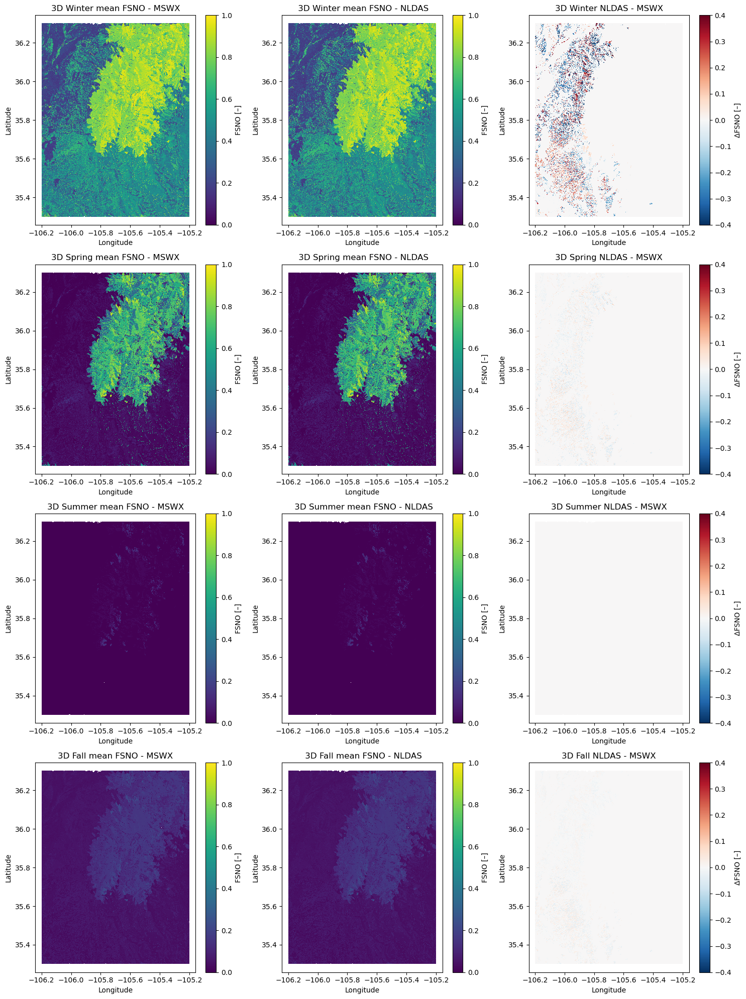

In [40]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# Paths
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_3d/"
path_nldas = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_3d/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# clean 2016 file
file_mswx  = path_mswx  + "output_data/1/2016-01-01.nc"
file_nldas = path_nldas + "output_data/1/2016-01-01.nc"


# HRU rasters
hrus_mswx = gdal_tools.read_raster(path_mswx + "postprocess/hrus.vrt")
cids_mswx = gdal_tools.read_raster(path_mswx + "postprocess/cids.vrt")
meta_mswx = gdal_tools.retrieve_metadata(path_mswx + "postprocess/hrus.vrt")

hrus_nldas = gdal_tools.read_raster(path_nldas + "postprocess/hrus.vrt")
cids_nldas = gdal_tools.read_raster(path_nldas + "postprocess/cids.vrt")
meta_nldas = gdal_tools.retrieve_metadata(path_nldas + "postprocess/hrus.vrt")

buffer = 250

# forcing coordinates
coord_xx0_mswx = np.linspace(meta_mswx["minx"], meta_mswx["maxx"], meta_mswx["nx"])
coord_yy0_mswx = np.linspace(meta_mswx["miny"], meta_mswx["maxy"], meta_mswx["ny"])
coords_x_mswx = coord_xx0_mswx[buffer:len(coord_xx0_mswx)-buffer+1]
coords_y_mswx = coord_yy0_mswx[buffer:len(coord_yy0_mswx)-buffer+1]

coord_xx0_nldas = np.linspace(meta_nldas["minx"], meta_nldas["maxx"], meta_nldas["nx"])
coord_yy0_nldas = np.linspace(meta_nldas["miny"], meta_nldas["maxy"], meta_nldas["ny"])
coords_x_nldas = coord_xx0_nldas[buffer:len(coord_xx0_nldas)-buffer+1]
coords_y_nldas = coord_yy0_nldas[buffer:len(coord_yy0_nldas)-buffer+1]

tmp_mswx = np.full(hrus_mswx.shape, -9999.0, dtype=np.float32)
tmp_nldas = np.full(hrus_nldas.shape, -9999.0, dtype=np.float32)

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

def read_fsno(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
    fp.close()
    return fsno

# Read FSNO
fsno_mswx = read_fsno(file_mswx)
fsno_nldas = read_fsno(file_nldas)

print("MSWX fsno shape :", fsno_mswx.shape)
print("NLDAS fsno shape:", fsno_nldas.shape)
print("MSWX hrus shape :", hrus_mswx.shape)
print("NLDAS hrus shape:", hrus_nldas.shape)


# Check compatibility
if fsno_mswx.shape[1] != np.nanmax(hrus_mswx):
    print("Warning: MSWX HRU count may not match fsno HRU dimension")

if fsno_nldas.shape[1] != np.nanmax(hrus_nldas):
    print("Warning: NLDAS HRU count may not match fsno HRU dimension")

same_grid = (
    hrus_mswx.shape == hrus_nldas.shape and
    meta_mswx["minx"] == meta_nldas["minx"] and
    meta_mswx["maxx"] == meta_nldas["maxx"] and
    meta_mswx["miny"] == meta_nldas["miny"] and
    meta_mswx["maxy"] == meta_nldas["maxy"]
)

print("Same plotting grid:", same_grid)

# same 2016–2018 3-hourly timeline for both forcing
ntime = fsno_mswx.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")


# Seasonal definitions
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# Plot MSWX vs NLDAS vs Difference
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

norm_fsno = colors.Normalize(vmin=0.0, vmax=1.0)
norm_diff = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

for row, season in enumerate(seasons):
    mask = times.month.isin(season_months[season])

    mswx_mean = np.nanmean(fsno_mswx[mask, :], axis=0)
    nldas_mean = np.nanmean(fsno_nldas[mask, :], axis=0)

    map_mswx = place_data(tmp_mswx, mswx_mean, hrus_mswx, cids_mswx, 1)
    map_nldas = place_data(tmp_nldas, nldas_mean, hrus_nldas, cids_nldas, 1)

    map_mswx = np.ma.masked_where(map_mswx == -9999.0, map_mswx)
    map_nldas = np.ma.masked_where(map_nldas == -9999.0, map_nldas)

    map_mswx = map_mswx[buffer:map_mswx.shape[0]-buffer+1,
                        buffer:map_mswx.shape[1]-buffer+1]
    map_nldas = map_nldas[buffer:map_nldas.shape[0]-buffer+1,
                          buffer:map_nldas.shape[1]-buffer+1]

    # difference only safe if final mapped grids are same shape
    if map_mswx.shape != map_nldas.shape:
        raise ValueError(
            f"Mapped MSWX and NLDAS grids differ in shape: {map_mswx.shape} vs {map_nldas.shape}"
        )

    diff_mean = map_nldas - map_mswx

    ax0, ax1, ax2 = axes[row, :]

    im0 = ax0.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(map_mswx),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax0.set_title(f"3D {season} mean FSNO - MSWX")
    fig.colorbar(im0, ax=ax0, label="FSNO [–]")

    im1 = ax1.pcolormesh(
        coords_x_nldas, coords_y_nldas, np.flipud(map_nldas),
        cmap="viridis", norm=norm_fsno, shading="auto"
    )
    ax1.set_title(f" 3D {season} mean FSNO - NLDAS")
    fig.colorbar(im1, ax=ax1, label="FSNO [–]")

    im2 = ax2.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(diff_mean),
        cmap="RdBu_r", norm=norm_diff, shading="auto"
    )
    ax2.set_title(f"3D {season} NLDAS - MSWX")
    fig.colorbar(im2, ax=ax2, label="ΔFSNO [–]")

    for ax in [ax0, ax1, ax2]:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "3D seasonal_fsno_MSWX_vs_NLDAS_2016_2018.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [41]:
hru_idx = 999  # HRU 1000

fsno_hru = fsno_mswx[:, hru_idx]

print("FSNO stats for HRU 1000:")
print("Min :", np.nanmin(fsno_hru))
print("Max :", np.nanmax(fsno_hru))
print("Mean:", np.nanmean(fsno_hru))

FSNO stats for HRU 1000:
Min : 0.0
Max : 1.0
Mean: 0.05329855


In [42]:
print("All zeros?", np.all(fsno_hru == 0))
print("All NaN?", np.all(np.isnan(fsno_hru)))

All zeros? False
All NaN? False


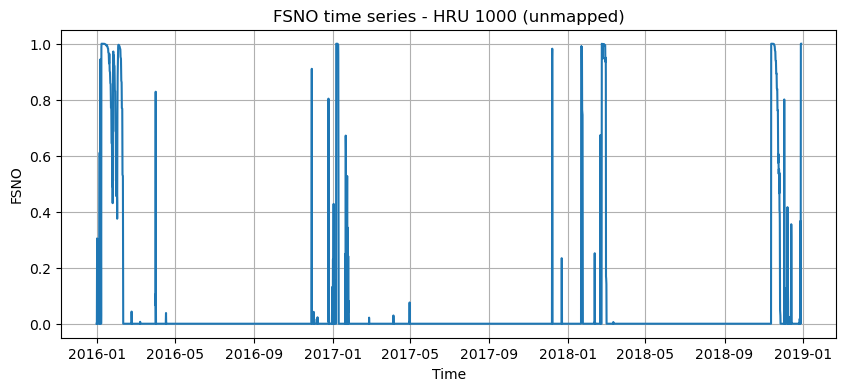

In [43]:
plt.figure(figsize=(10,4))
plt.plot(times, fsno_hru)
plt.title("FSNO time series - HRU 1000 (unmapped)")
plt.xlabel("Time")
plt.ylabel("FSNO")
plt.grid()
plt.show()

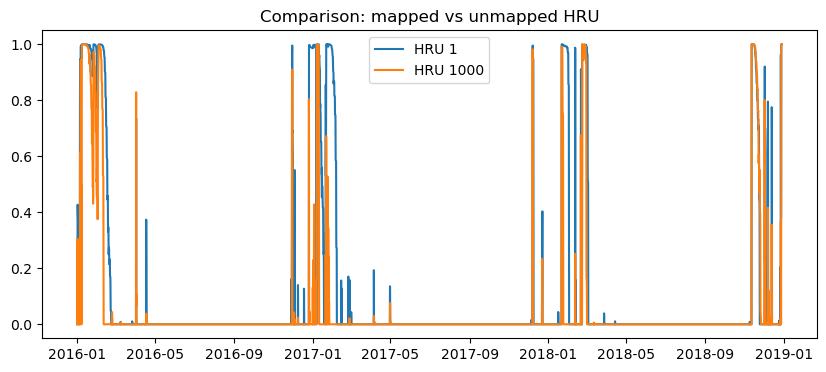

In [44]:
hru_ref = 0  # HRU 1

plt.figure(figsize=(10,4))
plt.plot(times, fsno_mswx[:, hru_ref], label="HRU 1")
plt.plot(times, fsno_hru, label="HRU 1000")
plt.legend()
plt.title("Comparison: mapped vs unmapped HRU")
plt.show()

In [45]:
fp = nc.Dataset(file_mswx)
grp = fp.groups["data"]

vars_to_check = ["swe", "snowh", "t2mb", "totsmc"]

for v in vars_to_check:
    data = np.array(grp.variables[v][:, hru_idx])
    print(f"\n{v} stats for HRU 1000:")
    print("  min :", np.nanmin(data))
    print("  max :", np.nanmax(data))
    print("  mean:", np.nanmean(data))

fp.close()


swe stats for HRU 1000:
  min : 0.0
  max : 8.394836
  mean: 0.2909734

snowh stats for HRU 1000:
  min : 0.0
  max : 0.088134766
  mean: 0.0018891093

t2mb stats for HRU 1000:
  min : 254.50464
  max : 307.63196
  mean: 284.77393

totsmc stats for HRU 1000:
  min : 0.1640625
  max : 0.3046875
  mean: 0.2127021


In [46]:
import numpy as np
import geospatialtools.gdal_tools as gdal_tools

mswx_grid_file = path_mswx + "postprocess/hrus.vrt"

meta_mswx = gdal_tools.retrieve_metadata(mswx_grid_file)

mswx_x = np.linspace(meta_mswx["minx"], meta_mswx["maxx"], meta_mswx["nx"])
mswx_y = np.linspace(meta_mswx["miny"], meta_mswx["maxy"], meta_mswx["ny"])

print("MSWX HydroBlocks raster info")
print("shape      :", (meta_mswx["ny"], meta_mswx["nx"]))
print("x min/max  :", meta_mswx["minx"], meta_mswx["maxx"])
print("y min/max  :", meta_mswx["miny"], meta_mswx["maxy"])
print("dx         :", mswx_x[1] - mswx_x[0])
print("dy         :", mswx_y[1] - mswx_y[0])
print("metadata   :", meta_mswx)

MSWX HydroBlocks raster info
shape      : (1801, 1801)
x min/max  : -106.45041666666549 -104.94958333333221
y min/max  : 35.049583333332606 36.55041666666588
dx         : 0.0008337962962912115
dy         : 0.000833796296298317
metadata   : {'proj4': '+proj=longlat +datum=WGS84 +no_defs', 'minx': -106.45041666666549, 'miny': 35.049583333332606, 'maxx': -104.94958333333221, 'maxy': 36.55041666666588, 'resx': 0.0008333333333333, 'resy': -0.0008333333333333, 'gt': (-106.45041666666549, 0.0008333333333333, 0.0, 36.55041666666588, 0.0, -0.0008333333333333), 'nx': 1801, 'ny': 1801, 'projection': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'}


In [47]:
import os
import glob
import rasterio
import numpy as np

smap_sat = "/scratch/alpine/battobrah@xsede.org/smap_monthly_smc_4326/"

# list files
files = sorted(glob.glob(os.path.join(smap_sat, "*.tif")))
print("Number of SMAP files:", len(files))

if len(files) == 0:
    raise RuntimeError("No .tif files found in the SMAP folder")

print("First file:", os.path.basename(files[0]))

# inspect first file
fp = files[0]
with rasterio.open(fp) as src:
    arr = src.read(1)

    print("\nSMAP file info")
    print("shape       :", arr.shape)
    print("crs         :", src.crs)
    print("bounds      :", src.bounds)
    print("resolution  :", src.res)
    print("transform   :", src.transform)
    print("dtype       :", arr.dtype)
    print("nodata      :", src.nodata)

    # valid values only
    arrf = arr.astype(float)
    if src.nodata is not None:
        arrf[arr == src.nodata] = np.nan

    print("\nValue stats")
    print("min         :", np.nanmin(arrf))
    print("max         :", np.nanmax(arrf))
    print("mean        :", np.nanmean(arrf))
    print("nan count   :", np.isnan(arrf).sum())

    # coordinate arrays
    x = src.transform.c + np.arange(src.width) * src.transform.a
    y = src.transform.f + np.arange(src.height) * src.transform.e

    print("\nx range     :", x.min(), x.max())
    print("y range     :", y.min(), y.max())
    print("dx          :", x[1] - x[0] if len(x) > 1 else None)
    print("dy          :", y[1] - y[0] if len(y) > 1 else None)

Number of SMAP files: 36
First file: SMAP_B1_201601_MODELGRID_4326_monthlymean.tif

SMAP file info
shape       : (1801, 1801)
crs         : EPSG:4326
bounds      : BoundingBox(left=-106.45041666666549, bottom=35.049583333332606, right=-104.94958333333221, top=36.55041666666588)
resolution  : (0.0008333333333333014, 0.0008333333333333014)
transform   : | 0.00, 0.00,-106.45|
| 0.00,-0.00, 36.55|
| 0.00, 0.00, 1.00|
dtype       : float32
nodata      : -9999.0

Value stats
min         : 0.005738049745559692
max         : 0.183389350771904
mean        : 0.09985369839631768
nan count   : 217304

x range     : -106.45041666666549 -104.95041666666555
y range     : 35.05041666666594 36.55041666666588
dx          : 0.0008333333333325754
dy          : -0.0008333333333325754


In [48]:
import os
import glob
import numpy as np
import xarray as xr

# folders
modscag_sinu = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU/"
modscag_modelgrid = "/scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL/"

def check_modscag_folder(folder):
    files = sorted(glob.glob(os.path.join(folder, "*.nc")))
    print("Folder:", folder)
    print("Number of files:", len(files))

    if len(files) == 0:
        print("No files found.")
        return

    ref_file = files[0]
    ds0 = xr.open_dataset(ref_file)

    print("\nReference file:", os.path.basename(ref_file))
    print("Variables:", list(ds0.data_vars))
    print("Coords:", list(ds0.coords))

    # detect coordinates
    if "x" in ds0.coords and "y" in ds0.coords:
        xname, yname = "x", "y"
    elif "lon" in ds0.coords and "lat" in ds0.coords:
        xname, yname = "lon", "lat"
    else:
        raise ValueError("Could not find x/y or lon/lat coordinates.")

    ref_x = ds0[xname].values
    ref_y = ds0[yname].values
    ref_shape = ds0["snow_fraction"].shape

    print("Reference shape:", ref_shape)
    print("Reference x range:", float(ref_x.min()), float(ref_x.max()))
    print("Reference y range:", float(ref_y.min()), float(ref_y.max()))
    print("Reference dx:", float(ref_x[1] - ref_x[0]) if len(ref_x) > 1 else None)
    print("Reference dy:", float(ref_y[1] - ref_y[0]) if len(ref_y) > 1 else None)

    ds0.close()

    bad_files = []

    for fp in files[1:]:
        ds = xr.open_dataset(fp)

        x = ds[xname].values
        y = ds[yname].values
        shape = ds["snow_fraction"].shape

        same_shape = (shape == ref_shape)
        same_x = (len(x) == len(ref_x)) and np.allclose(x, ref_x)
        same_y = (len(y) == len(ref_y)) and np.allclose(y, ref_y)

        if not (same_shape and same_x and same_y):
            bad_files.append({
                "file": os.path.basename(fp),
                "same_shape": same_shape,
                "same_x": same_x,
                "same_y": same_y,
                "shape": shape,
                "x_minmax": (float(x.min()), float(x.max())),
                "y_minmax": (float(y.min()), float(y.max())),
                "dx": float(x[1] - x[0]) if len(x) > 1 else None,
                "dy": float(y[1] - y[0]) if len(y) > 1 else None,
            })

        ds.close()

    print("\nSummary")
    if len(bad_files) == 0:
        print("All files have the same grid.")
    else:
        print(f"{len(bad_files)} files do NOT match the reference grid:")
        for item in bad_files[:10]:
            print(item)

# check both folders
check_modscag_folder(modscag_sinu)
print("\n" + "="*80 + "\n")
check_modscag_folder(modscag_modelgrid)

Folder: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU/
Number of files: 0
No files found.


Folder: /scratch/alpine/battobrah@xsede.org/MODSCAG_DOMAIN_MONTHLY_HBCLIP_SINU_MODELGRID_4326_ALL/
Number of files: 36

Reference file: MODSCAG_HBclip_ALLVARS_201601_MODELGRID_4326.nc
Variables: ['spatial_ref', 'albedo_clean_flat', 'albedo_dirty_flat', 'albedo_clean_terrain_corrected', 'albedo_dirty_terrain_corrected', 'deltavis', 'grain_size', 'drfs_grnsz', 'radiative_forcing', 'snow_fraction', 'viewable_snow_fraction', 'days_without_observation']
Coords: ['x', 'y']
Reference shape: (1801, 1801)
Reference x range: -106.44999999999882 -104.94999999999888
Reference y range: 35.04999999999927 36.549999999999216
Reference dx: 0.0008333333333325754
Reference dy: -0.0008333333333325754

Summary
All files have the same grid.


In [49]:
import os
import glob
import re
import xarray as xr
import numpy as np
import geospatialtools.gdal_tools as gdal_tools

# ----------------------------
# MODSCAG file list
# ----------------------------
mod_files = sorted(glob.glob(os.path.join(modscag_sat, "*.nc")))

mod_files = [fp for fp in mod_files if pat.match(os.path.basename(fp))]
print("Number of MODSCAG files found:", len(mod_files))
print("Example file:", os.path.basename(mod_files[0]))

mod_file = mod_files[0]

# ----------------------------
# Read MODSCAG grid info
# ----------------------------
ds = xr.open_dataset(mod_file)

print("\nMODSCAG dataset variables:")
print(list(ds.data_vars))
print("\nMODSCAG coordinates:")
print(list(ds.coords))

# try to identify lat/lon names
if "lat" in ds.coords and "lon" in ds.coords:
    lat_name, lon_name = "lat", "lon"
elif "y" in ds.coords and "x" in ds.coords:
    lat_name, lon_name = "y", "x"
else:
    raise ValueError("Could not find lat/lon or x/y coordinates in MODSCAG file")

mod_y = ds[lat_name].values
mod_x = ds[lon_name].values

print("\nMODSCAG grid info")
print("shape      :", (len(mod_y), len(mod_x)))
print("x min/max  :", float(np.min(mod_x)), float(np.max(mod_x)))
print("y min/max  :", float(np.min(mod_y)), float(np.max(mod_y)))

if len(mod_x) > 1:
    print("dx         :", float(mod_x[1] - mod_x[0]))
if len(mod_y) > 1:
    print("dy         :", float(mod_y[1] - mod_y[0]))

ds.close()

# ----------------------------
# Read NLDAS run raster grid info
# ----------------------------
meta_nldas = gdal_tools.retrieve_metadata(path_nldas + "postprocess/hrus.vrt")

nldas_x = np.linspace(meta_nldas["minx"], meta_nldas["maxx"], meta_nldas["nx"])
nldas_y = np.linspace(meta_nldas["miny"], meta_nldas["maxy"], meta_nldas["ny"])

print("\nNLDAS HydroBlocks raster info")
print("shape      :", (meta_nldas["ny"], meta_nldas["nx"]))
print("x min/max  :", meta_nldas["minx"], meta_nldas["maxx"])
print("y min/max  :", meta_nldas["miny"], meta_nldas["maxy"])

if len(nldas_x) > 1:
    print("dx         :", nldas_x[1] - nldas_x[0])
if len(nldas_y) > 1:
    print("dy         :", nldas_y[1] - nldas_y[0])

# ----------------------------
# Compare
# ----------------------------
same_shape = (len(mod_y), len(mod_x)) == (meta_nldas["ny"], meta_nldas["nx"])
same_x = (len(mod_x) == len(nldas_x)) and np.allclose(mod_x, nldas_x)
same_y = (len(mod_y) == len(nldas_y)) and np.allclose(mod_y, nldas_y)

print("\nGRID CHECK")
print("Same shape:", same_shape)
print("Same x    :", same_x)
print("Same y    :", same_y)

if same_shape and same_x and same_y:
    print("\nMODSCAG is on the same grid as the NLDAS HydroBlocks raster.")
else:
    print("\nMODSCAG is NOT exactly on the same grid as the NLDAS HydroBlocks raster.")

Number of MODSCAG files found: 36
Example file: MODSCAG_HBclip_ALLVARS_201601_MODELGRID_4326.nc

MODSCAG dataset variables:
['spatial_ref', 'albedo_clean_flat', 'albedo_dirty_flat', 'albedo_clean_terrain_corrected', 'albedo_dirty_terrain_corrected', 'deltavis', 'grain_size', 'drfs_grnsz', 'radiative_forcing', 'snow_fraction', 'viewable_snow_fraction', 'days_without_observation']

MODSCAG coordinates:
['x', 'y']

MODSCAG grid info
shape      : (1801, 1801)
x min/max  : -106.44999999999882 -104.94999999999888
y min/max  : 35.04999999999927 36.549999999999216
dx         : 0.0008333333333325754
dy         : -0.0008333333333325754

NLDAS HydroBlocks raster info
shape      : (1801, 1801)
x min/max  : -106.45041666666549 -104.94958333333221
y min/max  : 35.049583333332606 36.55041666666588
dx         : 0.0008337962962912115
dy         : 0.000833796296298317

GRID CHECK
Same shape: True
Same x    : True
Same y    : False

MODSCAG is NOT exactly on the same grid as the NLDAS HydroBlocks raster.

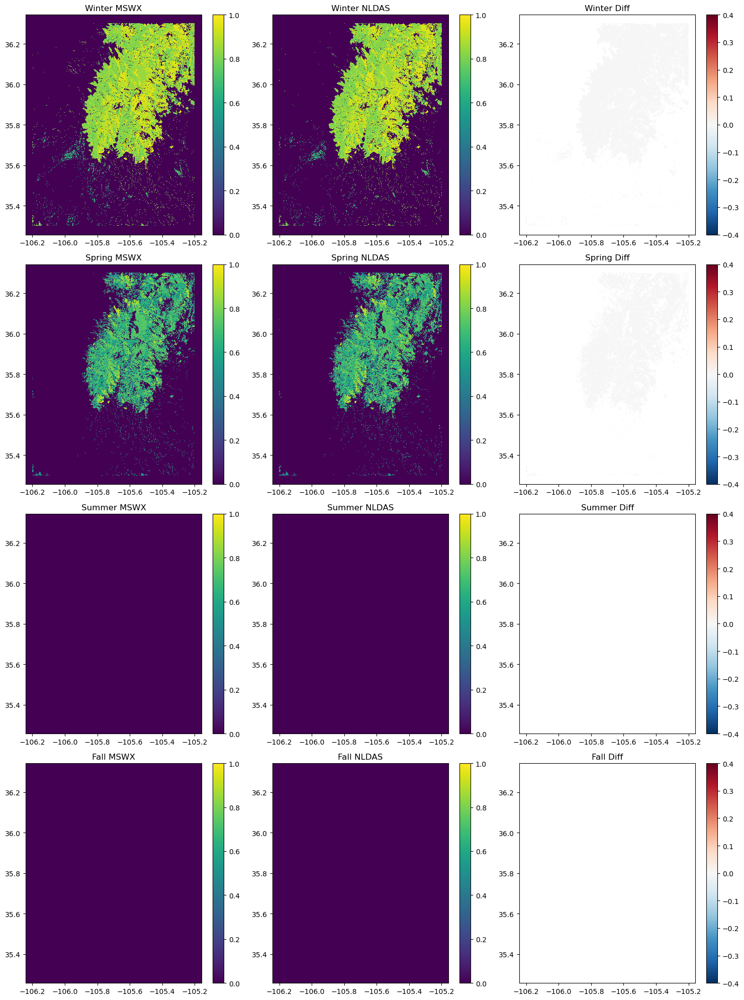

In [50]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# Paths
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/"
path_nldas = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# files
file_mswx  = path_mswx  + "output_data/1/2016-01-01.nc"
file_nldas = path_nldas + "output_data/1/2016-01-01.nc"

# ----------------------------
# USER CHOICE: SWE threshold
# ----------------------------
swe_threshold = 15.0

# HRU rasters
hrus_mswx = gdal_tools.read_raster(path_mswx + "postprocess/hrus.vrt")
cids_mswx = gdal_tools.read_raster(path_mswx + "postprocess/cids.vrt")
meta_mswx = gdal_tools.retrieve_metadata(path_mswx + "postprocess/hrus.vrt")

hrus_nldas = gdal_tools.read_raster(path_nldas + "postprocess/hrus.vrt")
cids_nldas = gdal_tools.read_raster(path_nldas + "postprocess/cids.vrt")
meta_nldas = gdal_tools.retrieve_metadata(path_nldas + "postprocess/hrus.vrt")

buffer = 250

# coordinates
coord_xx0_mswx = np.linspace(meta_mswx["minx"], meta_mswx["maxx"], meta_mswx["nx"])
coord_yy0_mswx = np.linspace(meta_mswx["miny"], meta_mswx["maxy"], meta_mswx["ny"])
coords_x_mswx = coord_xx0_mswx[buffer:len(coord_xx0_mswx)-buffer+1]
coords_y_mswx = coord_yy0_mswx[buffer:len(coord_yy0_mswx)-buffer+1]

coord_xx0_nldas = np.linspace(meta_nldas["minx"], meta_nldas["maxx"], meta_nldas["nx"])
coord_yy0_nldas = np.linspace(meta_nldas["miny"], meta_nldas["maxy"], meta_nldas["ny"])
coords_x_nldas = coord_xx0_nldas[buffer:len(coord_xx0_nldas)-buffer+1]
coords_y_nldas = coord_yy0_nldas[buffer:len(coord_yy0_nldas)-buffer+1]

tmp_mswx = np.full(hrus_mswx.shape, -9999.0, dtype=np.float32)
tmp_nldas = np.full(hrus_nldas.shape, -9999.0, dtype=np.float32)

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

def read_vars(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:], dtype=np.float32)
    swe  = np.array(grp.variables["swe"][:],  dtype=np.float32)
    fp.close()
    return fsno, swe

# read data
fsno_mswx, swe_mswx = read_vars(file_mswx)
fsno_nldas, swe_nldas = read_vars(file_nldas)

ntime = fsno_mswx.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

norm_fsno = colors.Normalize(vmin=0.0, vmax=1.0)
norm_diff = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

# define colormap with masked color same as low end
cmap_fsno = plt.cm.viridis.copy()
cmap_fsno.set_bad(color=cmap_fsno(0.0))

for row, season in enumerate(seasons):

    mask = times.month.isin(season_months[season])

    fsno_mswx_mean  = np.nanmean(fsno_mswx[mask, :], axis=0)
    fsno_nldas_mean = np.nanmean(fsno_nldas[mask, :], axis=0)

    swe_mswx_mean   = np.nanmean(swe_mswx[mask, :], axis=0)
    swe_nldas_mean  = np.nanmean(swe_nldas[mask, :], axis=0)

    map_mswx_fsno = place_data(tmp_mswx, fsno_mswx_mean, hrus_mswx, cids_mswx, 1)
    map_nldas_fsno = place_data(tmp_nldas, fsno_nldas_mean, hrus_nldas, cids_nldas, 1)

    map_mswx_swe = place_data(tmp_mswx, swe_mswx_mean, hrus_mswx, cids_mswx, 1)
    map_nldas_swe = place_data(tmp_nldas, swe_nldas_mean, hrus_nldas, cids_nldas, 1)

    # crop
    map_mswx_fsno = map_mswx_fsno[buffer:-buffer+1, buffer:-buffer+1]
    map_nldas_fsno = map_nldas_fsno[buffer:-buffer+1, buffer:-buffer+1]

    map_mswx_swe = map_mswx_swe[buffer:-buffer+1, buffer:-buffer+1]
    map_nldas_swe = map_nldas_swe[buffer:-buffer+1, buffer:-buffer+1]

    # mask
    map_mswx = np.ma.masked_where(
        (map_mswx_fsno == -9999.0) | (map_mswx_swe < swe_threshold),
        map_mswx_fsno
    )
    map_nldas = np.ma.masked_where(
        (map_nldas_fsno == -9999.0) | (map_nldas_swe < swe_threshold),
        map_nldas_fsno
    )

    diff_mean = map_nldas - map_mswx
    diff_mean = np.ma.masked_where(map_mswx.mask | map_nldas.mask, diff_mean)

    ax0, ax1, ax2 = axes[row, :]

    im0 = ax0.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(map_mswx),
        cmap=cmap_fsno, norm=norm_fsno, shading="auto"
    )
    ax0.set_title(f"{season} MSWX")

    im1 = ax1.pcolormesh(
        coords_x_nldas, coords_y_nldas, np.flipud(map_nldas),
        cmap=cmap_fsno, norm=norm_fsno, shading="auto"
    )
    ax1.set_title(f"{season} NLDAS")

    im2 = ax2.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(diff_mean),
        cmap="RdBu_r", norm=norm_diff, shading="auto"
    )
    ax2.set_title(f"{season} Diff")

    fig.colorbar(im0, ax=ax0)
    fig.colorbar(im1, ax=ax1)
    fig.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

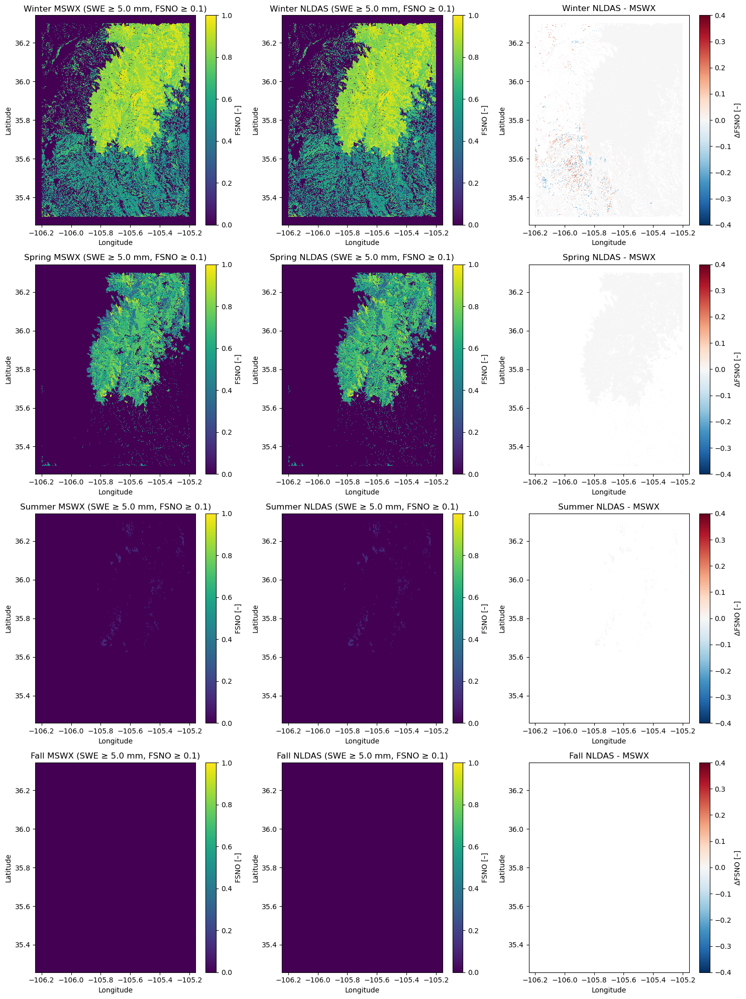

In [51]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

# Paths
path_mswx = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/partition_options/option_3/MSWX_3h_Snow_Project3_pp/"
path_nldas = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/NLDAS_forcing_plots"
os.makedirs(outputdir, exist_ok=True)

# files
file_mswx  = path_mswx  + "output_data/1/2016-01-01.nc"
file_nldas = path_nldas + "output_data/1/2016-01-01.nc"

# ----------------------------
# Threshold choices
# ----------------------------
swe_threshold = 5.0
fsno_threshold = 0.1

# HRU rasters
hrus_mswx = gdal_tools.read_raster(path_mswx + "postprocess/hrus.vrt")
cids_mswx = gdal_tools.read_raster(path_mswx + "postprocess/cids.vrt")
meta_mswx = gdal_tools.retrieve_metadata(path_mswx + "postprocess/hrus.vrt")

hrus_nldas = gdal_tools.read_raster(path_nldas + "postprocess/hrus.vrt")
cids_nldas = gdal_tools.read_raster(path_nldas + "postprocess/cids.vrt")
meta_nldas = gdal_tools.retrieve_metadata(path_nldas + "postprocess/hrus.vrt")

buffer = 250

# coordinates
coord_xx0_mswx = np.linspace(meta_mswx["minx"], meta_mswx["maxx"], meta_mswx["nx"])
coord_yy0_mswx = np.linspace(meta_mswx["miny"], meta_mswx["maxy"], meta_mswx["ny"])
coords_x_mswx = coord_xx0_mswx[buffer:len(coord_xx0_mswx)-buffer+1]
coords_y_mswx = coord_yy0_mswx[buffer:len(coord_yy0_mswx)-buffer+1]

coord_xx0_nldas = np.linspace(meta_nldas["minx"], meta_nldas["maxx"], meta_nldas["nx"])
coord_yy0_nldas = np.linspace(meta_nldas["miny"], meta_nldas["maxy"], meta_nldas["ny"])
coords_x_nldas = coord_xx0_nldas[buffer:len(coord_xx0_nldas)-buffer+1]
coords_y_nldas = coord_yy0_nldas[buffer:len(coord_yy0_nldas)-buffer+1]

tmp_mswx = np.full(hrus_mswx.shape, -9999.0, dtype=np.float32)
tmp_nldas = np.full(hrus_nldas.shape, -9999.0, dtype=np.float32)

def place_data(tmp, model, hrus, cids, cid_val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == cid_val):
                out[i, j] = model[hru - 1]
    return out

def read_vars(ncfile):
    fp = nc.Dataset(ncfile)
    grp = fp.groups["data"]
    fsno = np.array(grp.variables["fsno"][:], dtype=np.float32)
    swe  = np.array(grp.variables["swe"][:], dtype=np.float32)
    fp.close()
    return fsno, swe

# read data
fsno_mswx, swe_mswx = read_vars(file_mswx)
fsno_nldas, swe_nldas = read_vars(file_nldas)

ntime = fsno_mswx.shape[0]
times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

norm_fsno = colors.Normalize(vmin=0.0, vmax=1.0)
norm_diff = colors.TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

# colormap with masked values shown as the low-end color
cmap_fsno = plt.cm.viridis.copy()
cmap_fsno.set_bad(color=cmap_fsno(0.0))

for row, season in enumerate(seasons):

    mask = times.month.isin(season_months[season])

    fsno_mswx_mean  = np.nanmean(fsno_mswx[mask, :], axis=0)
    fsno_nldas_mean = np.nanmean(fsno_nldas[mask, :], axis=0)

    swe_mswx_mean   = np.nanmean(swe_mswx[mask, :], axis=0)
    swe_nldas_mean  = np.nanmean(swe_nldas[mask, :], axis=0)

    map_mswx_fsno = place_data(tmp_mswx, fsno_mswx_mean, hrus_mswx, cids_mswx, 1)
    map_nldas_fsno = place_data(tmp_nldas, fsno_nldas_mean, hrus_nldas, cids_nldas, 1)

    map_mswx_swe = place_data(tmp_mswx, swe_mswx_mean, hrus_mswx, cids_mswx, 1)
    map_nldas_swe = place_data(tmp_nldas, swe_nldas_mean, hrus_nldas, cids_nldas, 1)

    # crop
    map_mswx_fsno = map_mswx_fsno[buffer:-buffer+1, buffer:-buffer+1]
    map_nldas_fsno = map_nldas_fsno[buffer:-buffer+1, buffer:-buffer+1]

    map_mswx_swe = map_mswx_swe[buffer:-buffer+1, buffer:-buffer+1]
    map_nldas_swe = map_nldas_swe[buffer:-buffer+1, buffer:-buffer+1]

    # combined mask: remove weak snow mass and weak fractional cover
    map_mswx = np.ma.masked_where(
        (map_mswx_fsno == -9999.0) |
        (map_mswx_swe < swe_threshold) |
        (map_mswx_fsno < fsno_threshold),
        map_mswx_fsno
    )

    map_nldas = np.ma.masked_where(
        (map_nldas_fsno == -9999.0) |
        (map_nldas_swe < swe_threshold) |
        (map_nldas_fsno < fsno_threshold),
        map_nldas_fsno
    )

    diff_mean = map_nldas - map_mswx
    diff_mean = np.ma.masked_where(map_mswx.mask | map_nldas.mask, diff_mean)

    ax0, ax1, ax2 = axes[row, :]

    im0 = ax0.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(map_mswx),
        cmap=cmap_fsno, norm=norm_fsno, shading="auto"
    )
    ax0.set_title(f"{season} MSWX (SWE ≥ {swe_threshold} mm, FSNO ≥ {fsno_threshold})")
    fig.colorbar(im0, ax=ax0, label="FSNO [–]")

    im1 = ax1.pcolormesh(
        coords_x_nldas, coords_y_nldas, np.flipud(map_nldas),
        cmap=cmap_fsno, norm=norm_fsno, shading="auto"
    )
    ax1.set_title(f"{season} NLDAS (SWE ≥ {swe_threshold} mm, FSNO ≥ {fsno_threshold})")
    fig.colorbar(im1, ax=ax1, label="FSNO [–]")

    im2 = ax2.pcolormesh(
        coords_x_mswx, coords_y_mswx, np.flipud(diff_mean),
        cmap="RdBu_r", norm=norm_diff, shading="auto"
    )
    ax2.set_title(f"{season} NLDAS - MSWX")
    fig.colorbar(im2, ax=ax2, label="ΔFSNO [–]")

    for ax in [ax0, ax1, ax2]:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [54]:
import numpy as np
import pandas as pd
import os

# ----------------------------
# helper function
# ----------------------------
def compute_map_metrics(a, b):
    mask = np.isfinite(a) & np.isfinite(b)

    if np.sum(mask) == 0:
        return np.nan, np.nan

    aa = a[mask]
    bb = b[mask]

    mean_diff = np.mean(aa - bb)
    mean_abs_diff = np.mean(np.abs(aa - bb))

    return mean_diff, mean_abs_diff

# ----------------------------
# seasons
# ----------------------------
season_dict = {
    "Winter": (12, 1, 2),
    "Spring": (3, 4, 5),
    "Summer": (6, 7, 8),
    "Fall":   (9, 10, 11),
}

rows = []

for season_name, months in season_dict.items():
    print(f"Processing {season_name} ...")

    # seasonal maps
    pp_map  = get_fsno_map(path_pp, months)
    map_3d  = get_fsno_map(path_3d, months)
    mod_map = modscag_season_mean(modscag_rows, months)

    if mod_map is None:
        print(f"No MODSCAG data for {season_name}")
        continue

    # ----------------------------
    # align MODSCAG to HydroBlocks orientation and cropped domain
    # ----------------------------
    mod_map = (mod_map)
    mod_map = mod_map[buffer:mod_map.shape[0]-buffer+1,
                      buffer:mod_map.shape[1]-buffer+1]

    # convert MODSCAG percent -> fraction
    mod_map = mod_map / 100.0

    # ----------------------------
    # compute metrics on MAPS directly
    # ----------------------------
    md_pp_3d,  mad_pp_3d  = compute_map_metrics(pp_map, map_3d)
    md_pp_mod, mad_pp_mod = compute_map_metrics(pp_map, mod_map)
    md_3d_mod, mad_3d_mod = compute_map_metrics(map_3d, mod_map)

    rows.append({
        "Season": season_name,
        "PP_vs_3D_MeanDiff": md_pp_3d,
        "PP_vs_3D_MeanAbsDiff": mad_pp_3d,
        "PP_vs_MODSCAG_MeanDiff": md_pp_mod,
        "PP_vs_MODSCAG_MeanAbsDiff": mad_pp_mod,
        "3D_vs_MODSCAG_MeanDiff": md_3d_mod,
        "3D_vs_MODSCAG_MeanAbsDiff": mad_3d_mod,
    })

# ----------------------------
# table
# ----------------------------
df = pd.DataFrame(rows)
df = df.round(4)

print("\nSeasonal map-based metrics table:\n")
print(df)

# save table
#outfile = os.path.join(outputdir, "seasonal_map_mean_diff_mean_abs_diff_table.csv")
#df.to_csv(outfile, index=False)
#print(f"\nSaved to: {outfile}")

Processing Winter ...


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/971452023.py:125: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing Spring ...
Processing Summer ...


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2196159/971452023.py:125: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(arrs, axis=0), axis=0)


Processing Fall ...

Seasonal map-based metrics table:

   Season  PP_vs_3D_MeanDiff  PP_vs_3D_MeanAbsDiff  PP_vs_MODSCAG_MeanDiff  \
0  Winter             0.0125                0.0195                  0.3535   
1  Spring             0.0036                0.0068                  0.1604   
2  Summer            -0.0005                0.0006                  0.0018   
3    Fall             0.0015                0.0022                  0.0565   

   PP_vs_MODSCAG_MeanAbsDiff  3D_vs_MODSCAG_MeanDiff  \
0                     0.3601                  0.3410   
1                     0.1674                  0.1568   
2                     0.0029                  0.0023   
3                     0.0608                  0.0550   

   3D_vs_MODSCAG_MeanAbsDiff  
0                     0.3480  
1                     0.1640  
2                     0.0034  
3                     0.0594  


In [59]:
import numpy as np
import pandas as pd
import netCDF4 as nc
import os

# ----------------------------
# paths
# ----------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/"

# ----------------------------
# read fsno
# ----------------------------
def read_fsno(ncfile):
    fp = nc.Dataset(ncfile)
    fsno = np.array(fp.groups["data"].variables["fsno"][:], dtype=np.float32)  # (time, hru)
    fp.close()
    return fsno

# ----------------------------
# seasonal mean FSNO by HRU
# ----------------------------
def get_fsno_hru_mean(path, months):
    ncfile = os.path.join(path, "output_data/1/2016-01-01.nc")
    fsno = read_fsno(ncfile)

    ntime = fsno.shape[0]
    times = pd.date_range("2016-01-01 00:00:00", periods=ntime, freq="3H")

    mask = times.month.isin(months)
    fsno_mean = np.nanmean(fsno[mask, :], axis=0)   # (hru,)

    return fsno_mean

# ----------------------------
# metrics
# ----------------------------
def compute_direct_metrics(a, b):
    mask = np.isfinite(a) & np.isfinite(b)

    if np.sum(mask) == 0:
        return np.nan, np.nan

    aa = a[mask]
    bb = b[mask]

    mean_diff = np.mean(aa - bb)
    mean_abs_diff = np.mean(np.abs(aa - bb))

    return mean_diff, mean_abs_diff

# ----------------------------
# seasons
# ----------------------------
season_dict = {
    "Winter": (12, 1, 2),
    "Spring": (3, 4, 5),
    "Summer": (6, 7, 8),
    "Fall":   (9, 10, 11),
}

rows = []

for season_name, months in season_dict.items():
    print(f"Processing {season_name} ...")

    fsno_pp = get_fsno_hru_mean(path_pp, months)
    fsno_3d = get_fsno_hru_mean(path_3d, months)

    mean_diff, mean_abs_diff = compute_direct_metrics(fsno_pp, fsno_3d)

    rows.append({
        "Season": season_name,
        "PP - 3D_MeanDiff": mean_diff,
        "PP - 3D_MeanAbsDiff": mean_abs_diff
    })

df = pd.DataFrame(rows).round(4)

print("\nPP vs 3D seasonal table:\n")
print(df)

# optional save
#outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots"
#os.makedirs(outputdir, exist_ok=True)

#outfile = os.path.join(outputdir, "pp_vs_3d_seasonal_direct_metrics.csv")
#df.to_csv(outfile, index=False)
#print(f"\nSaved to: {outfile}")

Processing Winter ...
Processing Spring ...
Processing Summer ...
Processing Fall ...

PP vs 3D seasonal table:

   Season  PP - 3D_MeanDiff  PP - 3D_MeanAbsDiff
0  Winter            0.0085               0.0226
1  Spring            0.0010               0.0069
2  Summer           -0.0000               0.0001
3    Fall            0.0011               0.0024
